libaraies

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import butter, filtfilt, resample_poly, resample, find_peaks
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon
import scipy

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [2]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [3]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [4]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [5]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [6]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


In [7]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Load respiration from .h5, anti-alias LPF at raw fs, resample to target_rate,
    band-pass clean, and return (signal, time, fs_out).
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = float(ekg_meta['duration_sec'])
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # --- Anti-alias LPF at raw fs ---
    if target_rate >= fs:
        # No decimation needed; still low-pass a bit to remove HF noise
        cutoff_hz = min(0.45 * fs, 20.0)  # keep it sensible if fs is small
        Wn = cutoff_hz / (fs / 2.0)
    else:
        cutoff_hz = target_rate / 2.0       # classic anti-alias cutoff
        Wn = cutoff_hz / (fs / 2.0)

    Wn = min(max(Wn, 0.0001), 0.9999)       # clamp for safety
    b, a = butter(N=4, Wn=Wn, btype='low')
    filtered = filtfilt(b, a, resp)

    # --- Resample to EXACT target_rate ---
    # Prefer exact-length resample to avoid floor issues
    N_out = int(round(duration_sec * target_rate))
    # If you prefer polyphase, use Fraction to get integers:
    # from fractions import Fraction
    # frac = Fraction(target_rate, int(round(fs))).limit_denominator()
    # resampled = resample_poly(filtered, up=frac.numerator, down=frac.denominator)
    resampled = scipy.signal.resample(filtered, N_out)

    # --- Final band-pass clean at the new fs ---
    # Keep physiological band; adjust if you know your spectrum well
    lowcut, highcut = 0.1, 15.0
    rsp_cleaned = nk.signal_filter(
        resampled, lowcut=lowcut, highcut=highcut,
        method="butterworth", sampling_rate=target_rate, order=2
    )

    time_vector = np.arange(len(rsp_cleaned)) / float(target_rate)  # ✅ correct
    return rsp_cleaned, time_vector, float(target_rate)

In [8]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [9]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


In [10]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute average breathing rate (Hz) within a time window.

    Parameters
    ----------
    signal : array
        Respiration signal.
    time : array
        Time vector (seconds).
    sniff_start, sniff_end : float
        Start and end of window (can be a behavioral bout or full trial).
    sampling_rate : float
        Sampling rate of the signal (Hz). Default=100.

    Returns
    -------
    rate : float
        Average respiration rate (Hz) across the window.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # ≥12 Hz refractory
    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate


In [11]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout or whole trial.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # ≥12 Hz refractory
    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate


In [12]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout or whole trial ie sniff_start = trial_start and sniff_end = trial_end.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 seconds corresponds to 12 Hz

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

In [50]:
import numpy as np
from scipy.signal import find_peaks

def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) and inter-breath intervals (IBI) within a time window.

    Parameters
    ----------
    signal : array
        Respiration signal.
    time : array
        Time vector (seconds).
    sniff_start, sniff_end : float
        Start and end of window (can be a behavioral bout or full trial).
    sampling_rate : float
        Sampling rate of the signal (Hz). Default=100.

    Returns
    -------
    rate : float
        Average respiration rate (Hz) across the window.
    ibi_values : array
        Inter-breath intervals (s) between successive peaks in the window.
    mean_ibi : float
        Average IBI (s) across the window, or NaN if <2 peaks.
    """
    # Mask for time window
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # Detect peaks (enforce ≥12 Hz refractory → 0.083 s min distance)
    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)

    # Compute respiration rate
    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    # Compute IBIs (time difference between consecutive peaks)
    if len(peaks) >= 2:
        ibi_values = np.diff(time_sniff[peaks])
        mean_ibi = np.mean(ibi_values)
    else:
        ibi_values = np.array([])
        mean_ibi = np.nan

    return rate, ibi_values, mean_ibi


In [55]:
def extract_agent_face_sniffs_with_subject(df):
    """
    Extract facial sniffing by social agent, bouts >=1 sec,
    and add a 'Subject_ID' column parsed from 'Observation id'.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    def parse_subject_id(obs_id):
        parts = str(obs_id).split('_')
        if len(parts) >= 3:
            return '_'.join(parts[:3])
        else:
            return np.nan

    df['Subject_ID'] = df['Observation id'].apply(parse_subject_id)

    agent_mask = df['Subject'].str.lower() == 'social_agent'
    sniff_mask = df['Behavior'].str.lower() == 'facial sniffing'

    filtered = df[agent_mask & sniff_mask].copy()
    filtered['Duration'] = filtered['Stop (s)'] - filtered['Start (s)']
    filtered = filtered[filtered['Duration'] >= 1]



    return filtered


ONE SUBJECT 3.6 WORKED

In [56]:
face_sniffs = extract_agent_face_sniffs_with_subject(RI1_3_6_boris)
print(face_sniffs[['Observation id', 'Subject_ID', 'Start (s)', 'Stop (s)', 'Duration']].head())


        Observation id Subject_ID  Start (s)  Stop (s)  Duration
17  RI1_s3_6_p5_3_nRB3   RI1_s3_6     86.207    87.414     1.207
28  RI1_s3_6_p5_3_nRB3   RI1_s3_6    337.172   339.552     2.380


RUN LOOP ON ALL SUBJECTS WORKS

In [15]:
all_agent_sniffs = []

for label, boris_df in ri1_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs_with_subject(boris_df)
    agent_sniffs["Trial"] = label
    agent_sniffs["Group"] = "RI1"
    all_agent_sniffs.append(agent_sniffs)

for label, boris_df in ri2_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs_with_subject(boris_df)
    agent_sniffs["Trial"] = label
    agent_sniffs["Group"] = "RI2"
    all_agent_sniffs.append(agent_sniffs)

combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)


In [49]:
combined_sniffs_df


,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop,Subject_ID,Duration,Trial,Group,Media file,Total length,FPS,Modifiers
0,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,86.207,87.414,1.207,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,2500.0,2535.0,NaN,NaN,NaN,NaN,RI1_s3_6,1.207,RI1_3_6,RI1,NaN,NaN,NaN,NaN
1,RI1_s3_6_p5_3_nRB3,2025-06-28 22:13:15.619,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,0.0,589.517,622.862,29.0,social_agent,23.313,facial sniffing,Not defined,STATE,337.172,339.552,2.380,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4,9779.0,9848.0,NaN,NaN,NaN,NaN,RI1_s3_6,2.380,RI1_3_6,RI1,NaN,NaN,NaN,NaN
2,RI1_s2_3_p5_3_nRB3_20250622_104059.1,2025-07-01 16:32:15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,social_agent,NaN,facial sniffing,NaN,STATE,72.223,75.223,3.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI1_s2_3,3.000,RI1_2_3,RI1,/Users/ayushjain/Downloads/RI1_s2_3_p5_3_nRB3_20250622_104059.1.mov,602.00,30.0,NaN
3,RI1_s4_8_p5_1_nRB3,2025-07-02 21:32:00.524,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_8_p5_1_nRB3_20250621_165214.1.mp4,0.0,526.234,603.200,30.0,social_agent,26.430,facial sniffing,Not defined,STATE,324.800,326.133,1.333,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_8_p5_1_nRB3_20250621_165214.1.mp4,9745.0,9785.0,NaN,NaN,NaN,NaN,RI1_s4_8,1.333,RI1_4_8,RI1,NaN,NaN,NaN,NaN
4,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,social_agent,NaN,facial sniffing,NaN,STATE,227.831,229.078,1.247,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI1_s1_1,1.247,RI1_1_1,RI1,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_20250622_143958.1.mov,715.39,13.0,NaN
5,RI1_s2_4_p5_4_nRB3_20250622_123424.1,2025-07-03 16:17:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,social_agent,NaN,facial sniffing,NaN,STATE,157.267,160.067,2.800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI1_s2_4,2.800,RI1_2_4,RI1,/Users/ayushjain/Downloads/RI1_s2_4_p5_4_nRB3_20250622_123424.1.mov,607.73,15.0,NaN
6,RI1_s2_4_p5_4_nRB3_20250622_123424.1,2025-07-03 16:17:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,social_agent,NaN,facial sniffing,NaN,STATE,236.867,237.867,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI1_s2_4,1.000,RI1_2_4,RI1,/Users/ayushjain/Downloads/RI1_s2_4_p5_4_nRB3_20250622_123424.1.mov,607.73,15.0,NaN
7,RI1_s2_4_p5_4_nRB3_20250622_123424.1,2025-07-03 16:17:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,social_agent,NaN,facial sniffing,NaN,STATE,429.133,430.200,1.067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI1_s2_4,1.067,RI1_2_4,RI1,/Users/ayushjain/Downloads/RI1_s2_4_p5_4_nRB3_20250622_123424.1.mov,607.73,15.0,NaN
8,RI1_s2_4_p5_4_nRB3_20250622_123424.1,2025-07-03 16:17:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,social_agent,NaN,facial sniffing,NaN,STATE,465.400,467.267,1.867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI1_s2_4,1.867,RI1_2_4,RI1,/Users/ayushjain/Downloads/RI1_s2_4_p5_4_nRB3_20250622_123424.1.mov,607.73,15.0,NaN
9,RI1_s2_4_p5_4_nRB3_20250622_123424.1,2025-07-03 16:17:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,social_agent,NaN,facial sniffing,NaN,STATE,498.800,499.867,1.067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI1_s2_4,1.067,RI1_2_4,RI1,/Users/ayushjain/Downloads/RI1_s2_4_p5_4_nRB3_20250622_123424.1.mov,607.73,15.0,NaN


In [17]:
ri_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    sampling_rate = entry['sampling_rate']

    # Get full duration
    sniff_start = time[0]
    sniff_end = time[-1]

    # Compute respiration rate
    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=sampling_rate)

    # Get valence
    valence = 'RI1' if trial.startswith('RI1') else ('RI2' if trial.startswith('RI2') else 'Other')

    # Extract subject as 3.6 from RI1_3_6
    try:
        parts = trial.split('_')
        subject = f"{parts[1]}.{parts[2]}"
    except IndexError:
        subject = 'Unknown'

    ri_session_rates.append({
        'Trial': trial,
        'Valence': valence,
        'Subject': subject,
        'Respiration Rate (Hz)': rate
    })

# Convert to DataFrame
ri_session_df = pd.DataFrame(ri_session_rates)
print(ri_session_df.head())


     Trial Valence Subject  Respiration Rate (Hz)
0  RI1_3_6     RI1     3.6               7.371614
1  RI2_3_6     RI2     3.6               5.942720
2  RI1_4_7     RI1     4.7               7.750139
3  RI2_4_7     RI2     4.7               6.559377
4  RI1_2_3     RI1     2.3               7.337380


In [18]:
ri_session_df

,Trial,Valence,Subject,Respiration Rate (Hz)
0,RI1_3_6,RI1,3.6,7.371614
1,RI2_3_6,RI2,3.6,5.942720
2,RI1_4_7,RI1,4.7,7.750139
3,RI2_4_7,RI2,4.7,6.559377
4,RI1_2_3,RI1,2.3,7.337380
5,RI2_2_3,RI2,2.3,6.687569
6,RI1_4_8,RI1,4.8,7.557495
7,RI2_4_8,RI2,4.8,5.778890
8,RI1_1_1,RI1,1.1,7.517103
9,RI2_1_1,RI2,1.1,6.020371


Windows used:
#     - Baseline:  -1.5s to -0.5s before sniff_start
#     - Post-sniff: +0.5s to +1.5s after sniff_start

 # Define time windows
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)

In [19]:
def calculate_percent_change_resp_rate(signal, time, sniff_start, sampling_rate=100, plot=True,
                                      baseline_color='gray', sniff_color='orange', title=None):
    """
    Calculates % change in instantaneous respiration rate (Hz) around a sniff event.

    Windows used:
    - Baseline:  -5s to -1s before sniff_start (4 seconds)
    - During sniff: 0s to +0.5s after sniff_start (0.5 seconds)

    Args:
        signal (np.array): respiration signal array
        time (np.array): corresponding time array
        sniff_start (float): sniff event start time (seconds)
        sampling_rate (int): sampling rate of the signal (Hz)
        plot (bool): whether to plot the result
        baseline_color (color): color for baseline bar in plot
        sniff_color (color): color for sniff bar in plot
        title (str): custom title for the plot

    Returns:
        percent_change (float): % change in respiration rate during sniff vs baseline
        baseline_mean_rate (float): mean respiration rate during baseline window (Hz)
        sniff_mean_rate (float): mean respiration rate during sniff window (Hz)
    """
    # Define time windows
    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)

    baseline_segment = signal[baseline_mask]
    sniff_segment = signal[sniff_mask]

    min_distance_samples = int(0.0833 * sampling_rate)  # Min 75 ms between breaths

    # Detect peaks (breaths) in baseline and sniff windows
    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance_samples)
    sniff_peaks, _ = find_peaks(sniff_segment, distance=min_distance_samples)

    # Convert indices to actual time values for peaks
    baseline_peak_times = time[baseline_mask][baseline_peaks]
    sniff_peak_times = time[sniff_mask][sniff_peaks]

    # Calculate IBIs (time between peaks)
    baseline_ibis = np.diff(baseline_peak_times)
    sniff_ibis = np.diff(sniff_peak_times)

    if len(baseline_ibis) == 0 or len(sniff_ibis) == 0:
        if plot:
            print("Not enough peaks detected to calculate respiration rate change.")
        return None, None, None  # Not enough peaks to calculate

    # Instantaneous respiration rates (Hz) = 1 / IBI (seconds)
    baseline_rates = 1 / baseline_ibis
    sniff_rates = 1 / sniff_ibis

    # Calculate mean rates for baseline and sniff
    baseline_mean_rate = np.mean(baseline_rates)
    sniff_mean_rate = np.mean(sniff_rates)

    # Calculate percent change in respiration rate
    percent_change = ((sniff_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100

    if plot:
        plt.figure(figsize=(5, 4))
        plt.bar(['Baseline', 'During Sniff'], [baseline_mean_rate, sniff_mean_rate],
                color=[baseline_color, sniff_color])
        plt.ylabel('Respiration Rate (Hz)')
        if title is not None:
            plt.title(title)
        else:
            plt.title(f'Respiration Rate Change\n% Change: {percent_change:.2f}%')
        plt.show()

    return percent_change, baseline_mean_rate, sniff_mean_rate


In [20]:
results = []

for i, sniff_row in combined_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    # Get resp data for this trial
    resp_entry = resp_data.get(trial, None)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    percent_change, baseline_rate, post_rate = calculate_percent_change_resp_rate(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    if percent_change is None:
        print(f"Not enough peaks detected for sniff at {sniff_start}s in trial {trial}, skipping...")
        continue

    results.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Percent Change": percent_change,
        "Baseline Rate": baseline_rate,
        "Post-sniff Rate": post_rate
    })

results_df = pd.DataFrame(results)
print(results_df.head())

Not enough peaks detected for sniff at 488.333s in trial RI2_4_8, skipping...
     Trial  Sniff Start  Percent Change  Baseline Rate  Post-sniff Rate
0  RI1_3_6       86.207        9.749851       9.364731        10.277778
1  RI1_3_6      337.172       -2.759859       8.201714         7.975358
2  RI1_2_3       72.223       15.913461      10.544265        12.222222
3  RI1_4_8      324.800       19.532087       7.910988         9.456169
4  RI1_1_1      227.831       11.439154       8.701582         9.696970


C:\Users\sjs93\AppData\Local\Temp\ipykernel_32744\892775475.py:45: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


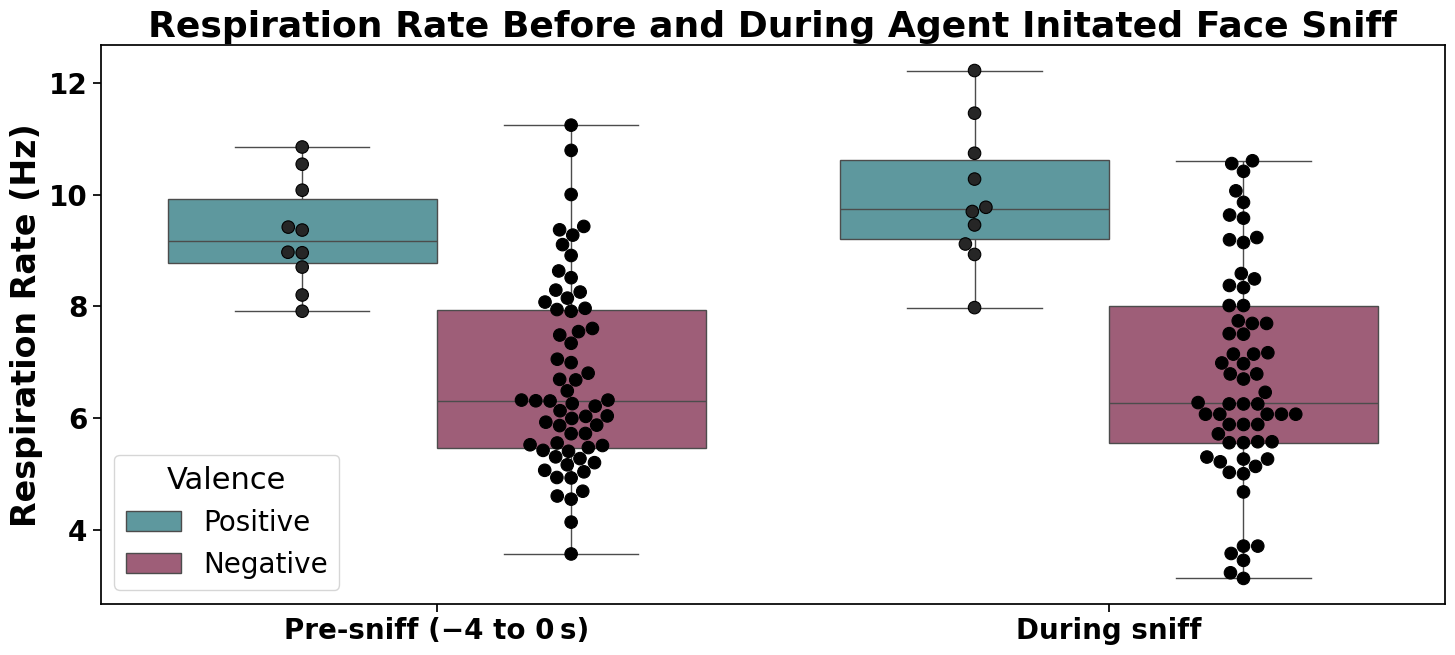

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette for positive and negative valence
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # RI1
    'Negative': (169/255, 83/255, 118/255)   # RI2
}

# Add 'Valence' column based on 'Trial' string
results_df['Valence'] = results_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
results_df = results_df[results_df['Valence'] != 'Unknown']

# Melt dataframe for plotting
plot_df = results_df.melt(
    id_vars=["Trial", "Valence"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename conditions for clarity
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−4 to 0 s)",
    "Post-sniff Rate": "During sniff"
})

# Set up plot
plt.figure(figsize=(15, 7))
sns.set_context("notebook", font_scale=1.8)

# Boxplot
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot overlay
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=9,
    marker='o',
    linewidth=0.8,
    legend=False
)

# Labels and formatting
plt.title("Respiration Rate Before and During Agent Initated Face Sniff", fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=24, weight='bold')
plt.xlabel('', fontsize=22)
plt.xticks(fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')
plt.legend(title='Valence', fontsize=20, title_fontsize=22, loc='lower left', bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_32744\2655796416.py:63: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


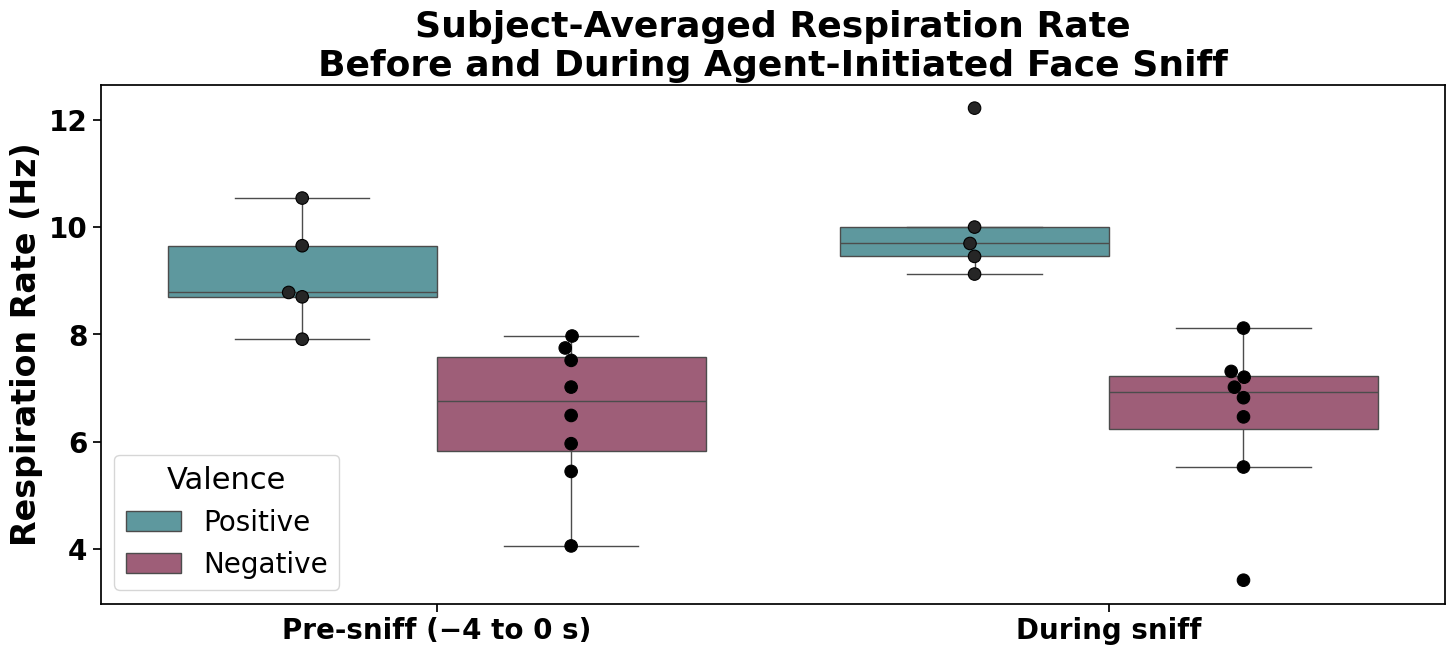

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Define color palette ----
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # Teal (RI1)
    'Negative': (169/255, 83/255, 118/255)   # Magenta (RI2)
}

# ---- Assign Valence from Trial ----
results_df['Valence'] = results_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
results_df = results_df[results_df['Valence'] != 'Unknown']

# ---- Extract Subject ID from Trial ----
# Example: "RI1_3_6" → "3_6"
results_df["Subject"] = results_df["Trial"].apply(lambda x: "_".join(x.split("_")[1:3]))

# ---- Melt dataframe to long format ----
plot_df = results_df.melt(
    id_vars=["Trial", "Valence", "Subject"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# ---- Rename conditions for clarity ----
plot_df["Condition"] = plot_df["Condition"].replace({
    "Baseline Rate": "Pre-sniff (−4 to 0 s)",
    "Post-sniff Rate": "During sniff"
})

# ---- Collapse to subject averages ----
avg_df = (
    plot_df
    .groupby(["Subject", "Valence", "Condition"], as_index=False)
    ["Respiration Rate (Hz)"]
    .mean()
)

# ---- Define plotting order ----
condition_order = ["Pre-sniff (−4 to 0 s)", "During sniff"]
valence_order = ["Positive", "Negative"]

# ---- Plot ----
plt.figure(figsize=(15, 7))
sns.set_context("notebook", font_scale=1.8)

# Boxplot of subject averages
sns.boxplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=avg_df,
    palette=custom_palette,
    fliersize=0,
    order=condition_order,
    hue_order=valence_order
)

# Overlay subject points
sns.swarmplot(
    x="Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=avg_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=9,
    marker='o',
    linewidth=0.8,
    order=condition_order,
    hue_order=valence_order,
    legend=False
)

# ---- Labels & legend ----
plt.title("Subject-Averaged Respiration Rate\nBefore and During Agent-Initiated Face Sniff",
          fontsize=26, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=24, weight='bold')
plt.xlabel('', fontsize=22)
plt.xticks(fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')
plt.legend(title='Valence', fontsize=20, title_fontsize=22,
           loc='lower left', bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.show()


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collapse to subject averages first
avg_df = (
    plot_df
    .groupby(["Subject", "Valence", "Condition"], as_index=False)
    ["Respiration Rate (Hz)"]
    .mean()
)

# Pivot so each subject has Pre and During in the same row
pivot_df = avg_df.pivot(
    index=["Subject", "Valence"],
    columns="Condition",
    values="Respiration Rate (Hz)"
).reset_index()

# Compute percent change
pivot_df["Percent Change"] = (
    (pivot_df["During sniff"] - pivot_df["Pre-sniff (−4 to 0 s)"]) 
    / pivot_df["Pre-sniff (−4 to 0 s)"] * 100
)


C:\Users\sjs93\AppData\Local\Temp\ipykernel_32744\1561892913.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


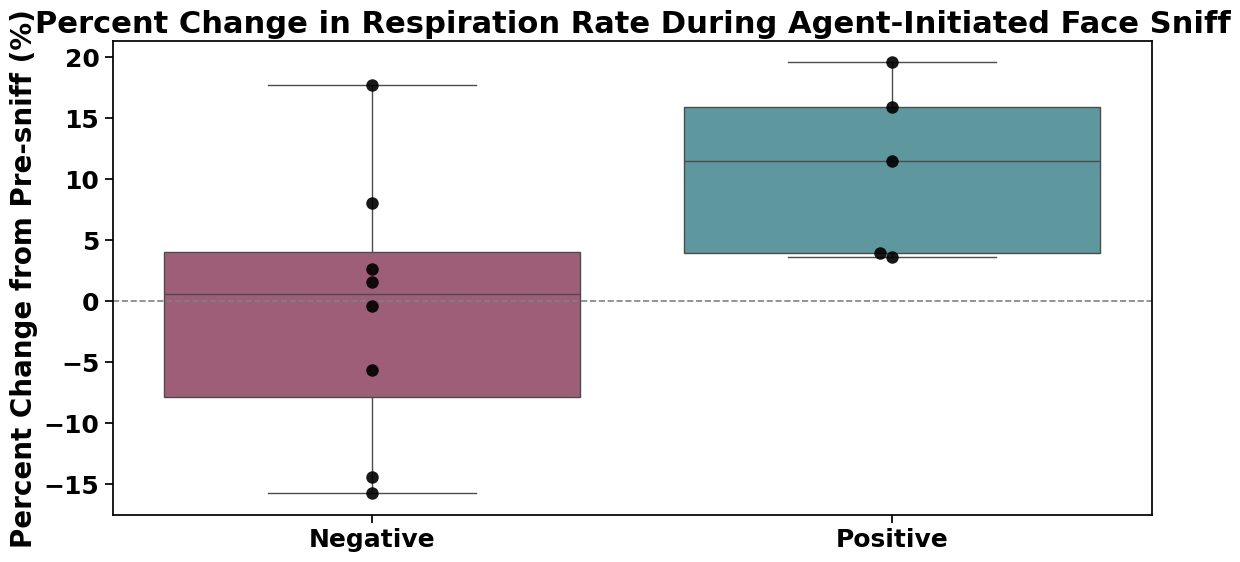

In [24]:
plt.figure(figsize=(12, 6))
sns.set_context("notebook", font_scale=1.6)

sns.boxplot(
    x="Valence",
    y="Percent Change",
    data=pivot_df,
    palette=custom_palette,
    fliersize=0
)

sns.swarmplot(
    x="Valence",
    y="Percent Change",
    data=pivot_df,
    color="black",
    size=9,
    alpha=0.9
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1.2)

plt.title("Percent Change in Respiration Rate During Agent-Initiated Face Sniff",
          fontsize=22, weight='bold')
plt.ylabel("Percent Change from Pre-sniff (%)", fontsize=20, weight='bold')
plt.xlabel("", fontsize=20)
plt.xticks(fontsize=18, weight='bold')
plt.yticks(fontsize=18, weight='bold')
plt.tight_layout()
plt.show()


In [25]:
# Count how many bouts went into each subject × valence × condition
bout_counts = (
    plot_df
    .groupby(["Subject", "Valence", "Condition"])
    .size()
    .reset_index(name="Bout_Count")
)

print(bout_counts)


   Subject   Valence              Condition  Bout_Count
0      1_1  Negative           During sniff           2
1      1_1  Negative  Pre-sniff (−4 to 0 s)           2
2      1_1  Positive           During sniff           1
3      1_1  Positive  Pre-sniff (−4 to 0 s)           1
4      1_2  Negative           During sniff          11
5      1_2  Negative  Pre-sniff (−4 to 0 s)          11
6      2_3  Negative           During sniff           7
7      2_3  Negative  Pre-sniff (−4 to 0 s)           7
8      2_3  Positive           During sniff           1
9      2_3  Positive  Pre-sniff (−4 to 0 s)           1
10     2_4  Negative           During sniff           9
11     2_4  Negative  Pre-sniff (−4 to 0 s)           9
12     2_4  Positive           During sniff           5
13     2_4  Positive  Pre-sniff (−4 to 0 s)           5
14     3_5  Negative           During sniff           3
15     3_5  Negative  Pre-sniff (−4 to 0 s)           3
16     3_6  Negative           During sniff     

sanity check

In [26]:
print("Subjects per valence BEFORE pivot:")
print(avg_df.groupby("Valence")["Subject"].nunique())

print("\nSubjects per valence AFTER pivot (used in percent change):")
print(pivot_df.groupby("Valence")["Subject"].nunique())


Subjects per valence BEFORE pivot:
Valence
Negative    8
Positive    5
Name: Subject, dtype: int64

Subjects per valence AFTER pivot (used in percent change):
Valence
Negative    8
Positive    5
Name: Subject, dtype: int64


In [27]:
results_df

,Trial,Sniff Start,Percent Change,Baseline Rate,Post-sniff Rate,Valence,Subject
0,RI1_3_6,86.207,9.749851,9.364731,10.277778,Positive,3_6
1,RI1_3_6,337.172,-2.759859,8.201714,7.975358,Positive,3_6
2,RI1_2_3,72.223,15.913461,10.544265,12.222222,Positive,2_3
3,RI1_4_8,324.800,19.532087,7.910988,9.456169,Positive,4_8
4,RI1_1_1,227.831,11.439154,8.701582,9.696970,Positive,1_1
5,RI1_2_4,157.267,5.581761,10.852569,11.458333,Positive,2_4
6,RI1_2_4,236.867,19.769593,8.967836,10.740741,Positive,2_4
7,RI1_2_4,429.133,-3.037157,10.078837,9.772727,Positive,2_4
8,RI1_2_4,465.400,-0.339352,8.958139,8.927739,Positive,2_4
9,RI1_2_4,498.800,-3.212396,9.417486,9.114959,Positive,2_4


In [28]:
# Extract Mouse ID from Trial (e.g. "RI1_3_6" -> "3_6")
results_df["Mouse"] = results_df["Trial"].apply(lambda x: "_".join(x.split("_")[1:]))

# Long format for baseline vs during
plot_df = results_df.melt(
    id_vars=["Mouse", "Valence"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

# Collapse to mouse averages
min_events = 5
mouse_summary = (
    plot_df.groupby(["Mouse", "Valence", "Condition"])
    .agg(
        Mean_Resp_Rate=("Respiration Rate (Hz)", "mean"),
        N_Events=("Respiration Rate (Hz)", "count")
    )
    .reset_index()
)

# Apply threshold
mouse_summary = mouse_summary[mouse_summary["N_Events"] >= min_events]


C:\Users\sjs93\AppData\Local\Temp\ipykernel_32744\1359253683.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


<Axes: xlabel='Condition', ylabel='Mean_Resp_Rate'>

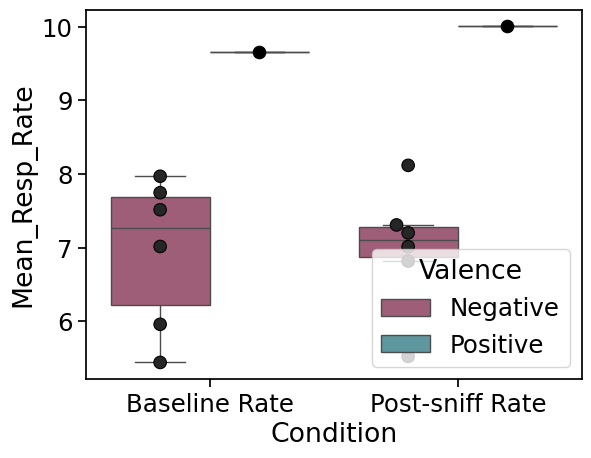

In [29]:
sns.boxplot(
    x="Condition",
    y="Mean_Resp_Rate",
    hue="Valence",
    data=mouse_summary,
    palette=custom_palette,
    fliersize=0
)

sns.swarmplot(
    x="Condition",
    y="Mean_Resp_Rate",
    hue="Valence",
    data=mouse_summary,
    dodge=True,
    color='black',
    size=9,
    marker='o',
    linewidth=0.8,
    legend=False
)


In [30]:
print(mouse_summary.head())


   Mouse   Valence        Condition  Mean_Resp_Rate  N_Events
4    1_2  Negative    Baseline Rate        7.747300        11
5    1_2  Negative  Post-sniff Rate        7.309721        11
6    2_3  Negative    Baseline Rate        7.516059         7
7    2_3  Negative  Post-sniff Rate        8.118132         7
10   2_4  Negative    Baseline Rate        7.017490         9


In [31]:
print(combined_sniffs_df["Behavior"].unique())
print(combined_sniffs_df.head())


['facial sniffing']
                         Observation id         Observation date  Description  \
0                    RI1_s3_6_p5_3_nRB3  2025-06-28 22:13:15.619          NaN   
1                    RI1_s3_6_p5_3_nRB3  2025-06-28 22:13:15.619          NaN   
2  RI1_s2_3_p5_3_nRB3_20250622_104059.1      2025-07-01 16:32:15          NaN   
3                    RI1_s4_8_p5_1_nRB3  2025-07-02 21:32:00.524          NaN   
4  RI1_s1_1_p5_2_nRB6_20250622_143958.1      2025-07-03 10:47:38          NaN   

  Observation type  \
0       Media file   
1       Media file   
2              NaN   
3       Media file   
4              NaN   

                                                                                           Source  \
0  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4   
1  player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s3_6_p5_3_nRB3_20250621_125312.1.mp4   
2                                                        

In [32]:
mouse_summary


,Mouse,Valence,Condition,Mean_Resp_Rate,N_Events
4,1_2,Negative,Baseline Rate,7.747300,11
5,1_2,Negative,Post-sniff Rate,7.309721,11
6,2_3,Negative,Baseline Rate,7.516059,7
7,2_3,Negative,Post-sniff Rate,8.118132,7
10,2_4,Negative,Baseline Rate,7.017490,9
11,2_4,Negative,Post-sniff Rate,7.202087,9
12,2_4,Positive,Baseline Rate,9.654973,5
13,2_4,Positive,Post-sniff Rate,10.002900,5
16,3_6,Negative,Baseline Rate,5.961474,9
17,3_6,Negative,Post-sniff Rate,7.015746,9


C:\Users\sjs93\AppData\Local\Temp\ipykernel_32744\4085731915.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, palette=["gray", "orange"])


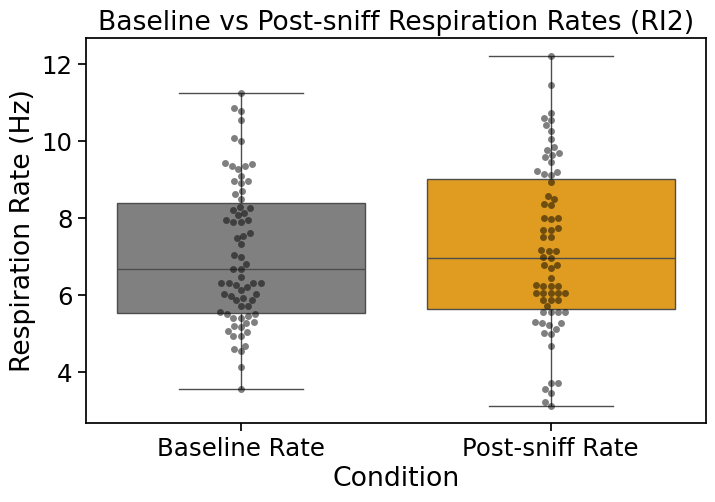

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape data for plotting baseline vs post side-by-side
plot_df = results_df.melt(
    id_vars=["Trial", "Sniff Start"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

plt.figure(figsize=(8, 5))
sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, palette=["gray", "orange"])
sns.swarmplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, color="black", alpha=0.5)

plt.title("Baseline vs Post-sniff Respiration Rates (RI2)")
plt.ylabel("Respiration Rate (Hz)")
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_32744\1314123701.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, palette=["gray", "orange"])


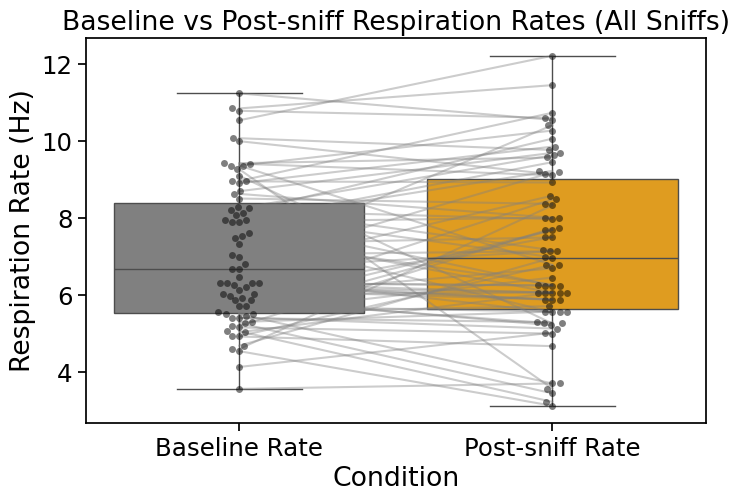

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = results_df.melt(
    id_vars=["Trial", "Sniff Start"],
    value_vars=["Baseline Rate", "Post-sniff Rate"],
    var_name="Condition",
    value_name="Respiration Rate (Hz)"
)

plt.figure(figsize=(8, 5))

# Boxplot
sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, palette=["gray", "orange"])

# Swarmplot with points
sns.swarmplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df, color="black", alpha=0.5)

# Connect points from same sniff event with lines
for (trial, sniff_start), group in plot_df.groupby(["Trial", "Sniff Start"]):
    if len(group) == 2:
        x_vals = [0, 1]  # Baseline is at x=0, Post-sniff at x=1
        y_vals = group.sort_values("Condition")["Respiration Rate (Hz)"].values
        plt.plot(x_vals, y_vals, color="gray", alpha=0.4)

plt.title("Baseline vs Post-sniff Respiration Rates (All Sniffs)")
plt.ylabel("Respiration Rate (Hz)")
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_32744\3168548869.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI1, palette=["gray", "orange"], ax=axes[0])
C:\Users\sjs93\AppData\Local\Temp\ipykernel_32744\3168548869.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI2, palette=["gray", "orange"], ax=axes[1])


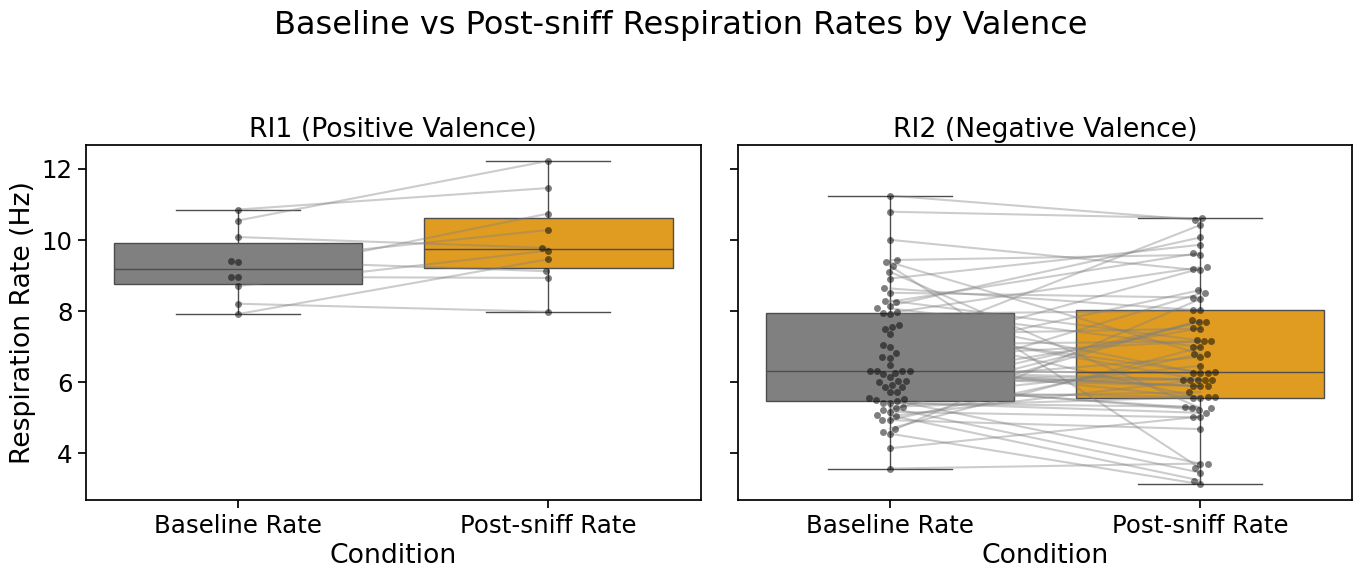

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for RI1 and RI2
plot_df_RI1 = plot_df[plot_df['Trial'].str.startswith('RI1')]
plot_df_RI2 = plot_df[plot_df['Trial'].str.startswith('RI2')]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for RI1
sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI1, palette=["gray", "orange"], ax=axes[0])
sns.swarmplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI1, color="black", alpha=0.5, ax=axes[0])

for (trial, sniff_start), group in plot_df_RI1.groupby(["Trial", "Sniff Start"]):
    if len(group) == 2:
        x_vals = [0, 1]
        y_vals = group.sort_values("Condition")["Respiration Rate (Hz)"].values
        axes[0].plot(x_vals, y_vals, color="gray", alpha=0.4)

axes[0].set_title("RI1 (Positive Valence)")
axes[0].set_ylabel("Respiration Rate (Hz)")

# Plot for RI2
sns.boxplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI2, palette=["gray", "orange"], ax=axes[1])
sns.swarmplot(x="Condition", y="Respiration Rate (Hz)", data=plot_df_RI2, color="black", alpha=0.5, ax=axes[1])

for (trial, sniff_start), group in plot_df_RI2.groupby(["Trial", "Sniff Start"]):
    if len(group) == 2:
        x_vals = [0, 1]
        y_vals = group.sort_values("Condition")["Respiration Rate (Hz)"].values
        axes[1].plot(x_vals, y_vals, color="gray", alpha=0.4)

axes[1].set_title("RI2 (Negative Valence)")
axes[1].set_ylabel("")  # No ylabel on right subplot to reduce clutter

plt.suptitle("Baseline vs Post-sniff Respiration Rates by Valence")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [36]:
sniff_rates = []

for i, sniff_row in combined_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]
    sniff_end = sniff_row["Stop (s)"]

    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=sampling_rate)

    sniff_rates.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Sniff End": sniff_end,
        "Sniff Duration": sniff_end - sniff_start,
        "Sniff Resp Rate (Hz)": rate
    })

sniff_rates_df = pd.DataFrame(sniff_rates)
print(sniff_rates_df.head())


     Trial  Sniff Start  Sniff End  Sniff Duration  Sniff Resp Rate (Hz)
0  RI1_3_6       86.207     87.414           1.207              7.456504
1  RI1_3_6      337.172    339.552           2.380              6.722689
2  RI1_2_3       72.223     75.223           3.000              9.333333
3  RI1_4_8      324.800    326.133           1.333              7.501875
4  RI1_1_1      227.831    229.078           1.247              8.019246


In [37]:
sniff_rates_df

,Trial,Sniff Start,Sniff End,Sniff Duration,Sniff Resp Rate (Hz)
0,RI1_3_6,86.207,87.414,1.207,7.456504
1,RI1_3_6,337.172,339.552,2.380,6.722689
2,RI1_2_3,72.223,75.223,3.000,9.333333
3,RI1_4_8,324.800,326.133,1.333,7.501875
4,RI1_1_1,227.831,229.078,1.247,8.019246
5,RI1_2_4,157.267,160.067,2.800,8.928571
6,RI1_2_4,236.867,237.867,1.000,8.000000
7,RI1_2_4,429.133,430.200,1.067,8.434864
8,RI1_2_4,465.400,467.267,1.867,6.963042
9,RI1_2_4,498.800,499.867,1.067,7.497657


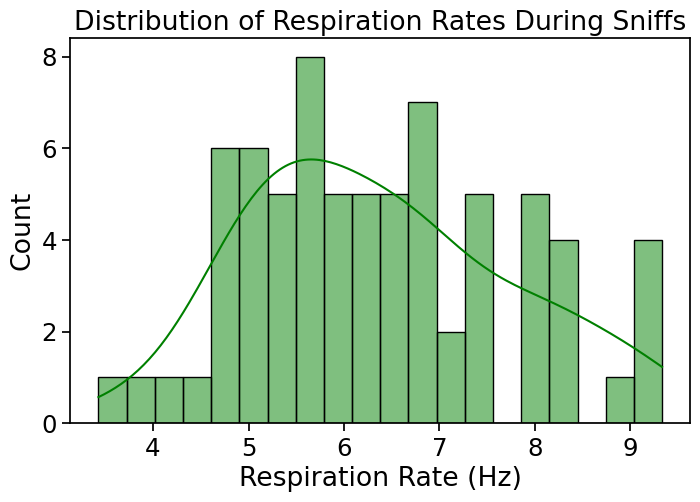

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(sniff_rates_df["Sniff Resp Rate (Hz)"], bins=20, kde=True, color="green")
plt.title("Distribution of Respiration Rates During Sniffs")
plt.xlabel("Respiration Rate (Hz)")
plt.ylabel("Count")
plt.show()


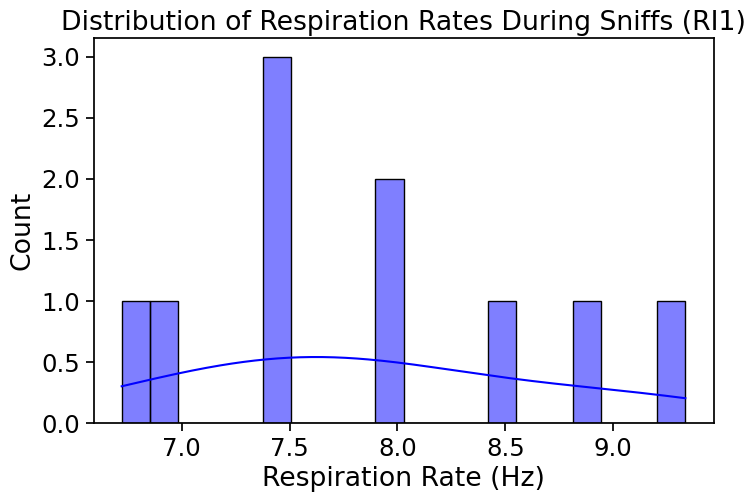

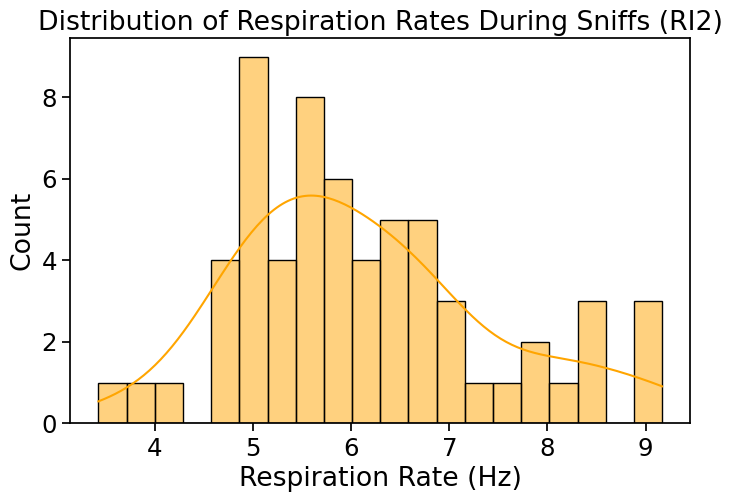

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter RI1 sniff rates
ri1_rates = sniff_rates_df[sniff_rates_df['Trial'].str.startswith('RI1')]

plt.figure(figsize=(8, 5))
sns.histplot(ri1_rates["Sniff Resp Rate (Hz)"], bins=20, kde=True, color="blue")
plt.title("Distribution of Respiration Rates During Sniffs (RI1)")
plt.xlabel("Respiration Rate (Hz)")
plt.ylabel("Count")
plt.show()

# Filter RI2 sniff rates
ri2_rates = sniff_rates_df[sniff_rates_df['Trial'].str.startswith('RI2')]

plt.figure(figsize=(8, 5))
sns.histplot(ri2_rates["Sniff Resp Rate (Hz)"], bins=20, kde=True, color="orange")
plt.title("Distribution of Respiration Rates During Sniffs (RI2)")
plt.xlabel("Respiration Rate (Hz)")
plt.ylabel("Count")
plt.show()


In [40]:
import pandas as pd

# Combine RI1 and RI2 BORIS data into one dataframe with a 'Trial' column
all_boris = []

for label, boris_df in {**ri1_boris_data, **ri2_boris_data}.items():
    df = boris_df.copy()
    df['Trial'] = label
    all_boris.append(df)

combined_boris_df = pd.concat(all_boris, ignore_index=True)

# Make sure Start and Stop are floats
combined_boris_df['Start (s)'] = combined_boris_df['Start (s)'].astype(float)
combined_boris_df['Stop (s)'] = combined_boris_df['Stop (s)'].astype(float)

# Calculate duration
combined_boris_df['Duration'] = combined_boris_df['Stop (s)'] - combined_boris_df['Start (s)']

# Filter by duration threshold (≥ 0.3 seconds)
filtered_behaviors = combined_boris_df[combined_boris_df['Duration'] >= 0.3]

# Prepare to store results
results = []

for idx, row in filtered_behaviors.iterrows():
    trial = row['Trial']
    subject = row['Subject'] 
    behavior = row['Behavior']
    start = row['Start (s)']
    stop = row['Stop (s)']

    # Get respiration data for the trial
    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry['signal']
    time = resp_entry['time']
    sampling_rate = resp_entry['sampling_rate']

    # Calculate respiratory rate during the behavior bout
    rate = get_sniff_respiratory_rate(signal, time, start, stop, sampling_rate=sampling_rate)

    results.append({
        'Trial': trial,
        'Subject': subject,
        'Behavior': behavior,
        'Start (s)': start,
        'Stop (s)': stop,
        'Duration (s)': stop - start,
        'Respiration Rate (Hz)': rate
    })

results_df = pd.DataFrame(results)

print(results_df.head())


     Trial       Subject             Behavior  Start (s)  Stop (s)  \
0  RI1_3_6  social_agent  anogenital sniffing      8.862     9.448   
1  RI1_3_6       subject      facial sniffing     11.966    13.000   
2  RI1_3_6  social_agent      facial sniffing     12.069    12.862   
3  RI1_3_6       subject  anogenital sniffing     14.483    16.690   
4  RI1_3_6       subject  anogenital sniffing     19.069    19.483   

   Duration (s)  Respiration Rate (Hz)  
0         0.586               5.119454  
1         1.034               6.769826  
2         0.793               7.566204  
3         2.207               8.608971  
4         0.414               4.830918  


In [41]:
results_df

,Trial,Subject,Behavior,Start (s),Stop (s),Duration (s),Respiration Rate (Hz)
0,RI1_3_6,social_agent,anogenital sniffing,8.862,9.448,0.586,5.119454
1,RI1_3_6,subject,facial sniffing,11.966,13.000,1.034,6.769826
2,RI1_3_6,social_agent,facial sniffing,12.069,12.862,0.793,7.566204
3,RI1_3_6,subject,anogenital sniffing,14.483,16.690,2.207,8.608971
4,RI1_3_6,subject,anogenital sniffing,19.069,19.483,0.414,4.830918
5,RI1_3_6,subject,anogenital sniffing,21.379,21.724,0.345,11.594203
6,RI1_3_6,subject,anogenital sniffing,25.034,27.552,2.518,8.339952
7,RI1_3_6,subject,body sniffing,27.793,28.448,0.655,9.160305
8,RI1_3_6,subject,anogenital sniffing,28.862,29.861,0.999,8.008008
9,RI1_3_6,subject,body sniffing,29.862,30.586,0.724,9.668508


In [42]:
results_df = pd.DataFrame(results)

# Normalize casing
results_df['Subject'] = results_df['Subject'].str.lower()


In [43]:
# Add Valence column BEFORE collapsing
results_df['Valence'] = results_df['Trial'].apply(
    lambda x: 'Positive Social Interaction' if x.startswith('RI1') else (
        'Negative Social Interaction' if x.startswith('RI2') else 'Other'
    )
)


In [44]:
# Collapse to subject-level means (one row per subject per behavior per trial)
subject_avg_df = (
    results_df
    .groupby(['Trial', 'Valence', 'Subject', 'Behavior'], as_index=False)
    .agg({'Respiration Rate (Hz)': 'mean'})
)

# Optional: extract subject IDs like 3_6 from RI1_3_6
subject_avg_df['Subject_ID'] = subject_avg_df['Trial'].apply(lambda x: "_".join(x.split('_')[1:3]))


In [45]:
# Collapse to subject-level means
subject_avg_df = (
    results_df
    .groupby(['Trial', 'Valence', 'Subject', 'Behavior'], as_index=False)
    .agg({'Respiration Rate (Hz)': 'mean'})
)

# Optional: extract subject IDs (3_6 from RI1_3_6)
subject_avg_df['Subject_ID'] = subject_avg_df['Trial'].apply(
    lambda x: "_".join(x.split('_')[1:3])
)


In [46]:
print(subject_avg_df.head())
print(subject_avg_df['Valence'].unique())


     Trial                      Valence       Subject             Behavior  \
0  RI1_1_1  Positive Social Interaction  social_agent        body sniffing   
1  RI1_1_1  Positive Social Interaction  social_agent      facial sniffing   
2  RI1_1_1  Positive Social Interaction       subject  anogenital sniffing   
3  RI1_1_1  Positive Social Interaction       subject        body sniffing   
4  RI1_1_1  Positive Social Interaction       subject      facial sniffing   

   Respiration Rate (Hz) Subject_ID  
0               8.487407        1_1  
1               8.019246        1_1  
2               7.721026        1_1  
3               7.518579        1_1  
4               7.237469        1_1  
['Positive Social Interaction' 'Negative Social Interaction']


In [47]:
pivot_df = subject_avg_df.pivot_table(
    index=['Subject_ID', 'Subject', 'Behavior'],  # keep Subject (initiator)
    columns='Valence',
    values='Respiration Rate (Hz)',
    aggfunc='mean'
).reset_index()

pivot_df.columns.name = None  # clean up
pivot_df


,Subject_ID,Subject,Behavior,Negative Social Interaction,Positive Social Interaction
0,1_1,social_agent,body sniffing,6.263341,8.487407
1,1_1,social_agent,chasing,7.352941,NaN
2,1_1,social_agent,facial sniffing,5.287463,8.019246
3,1_1,social_agent,fighting,6.303175,NaN
4,1_1,subject,Posturing,6.504407,NaN
5,1_1,subject,anogenital sniffing,6.394884,7.721026
6,1_1,subject,body sniffing,7.250000,7.518579
7,1_1,subject,facial sniffing,NaN,7.237469
8,1_2,social_agent,anogenital sniffing,6.830547,7.847176
9,1_2,social_agent,body sniffing,6.603995,8.583863


In [48]:
# Standardize behavior labels
behavior_label_map = {
    'facial sniffing': 'Facial Sniffing',
    'anogenital sniffing': 'Anogenital Sniffing',
    'body sniffing': 'Body Sniffing',
    'posturing': 'Posturing',
    'chasing': 'Chasing',
    'fighting': 'Fighting',
    'tails rattling': 'Tail Rattling'
}

collapsed_df['Behavior'] = (
    collapsed_df['Behavior']
    .str.strip().str.lower()                # clean spaces + lowercase
    .map(behavior_label_map)                # map to clean labels
    .fillna(collapsed_df['Behavior'])       # keep anything unmapped
)
collapsed_df['Initiator'] = collapsed_df['Initiator'].replace({
    'subject': 'Subject',
    'social_agent': 'Agent'
})
# Add subject IDs (e.g. 3_6 from RI1_3_6)
subject_avg_df['Subject_ID'] = subject_avg_df['Trial'].apply(lambda x: "_".join(x.split('_')[1:3]))


NameError: name 'collapsed_df' is not defined

In [ ]:
print(collapsed_df['Behavior'].unique())


NameError: name 'collapsed_df' is not defined

In [ ]:
print(collapsed_df.columns)
print(collapsed_df['Initiator'].unique())


Index(['Subject_ID', 'Initiator', 'Behavior', 'Valence',
       'Respiration Rate (Hz)'],
      dtype='object')
['Agent' 'Subject']


In [ ]:
pivot_df = subject_avg_df.pivot_table(
    index=['Subject_ID', 'Subject', 'Behavior'],
    columns='Valence',
    values='Respiration Rate (Hz)',
    aggfunc='mean'
).reset_index()

pivot_df.columns.name = None  # remove the "Valence" column header


In [ ]:
# Subject-initiated
subject_pos = pivot_df[['Subject_ID', 'Behavior', 'Positive Social Interaction']].dropna()
subject_pos = subject_pos.rename(columns={'Positive Social Interaction': 'Respiration Rate (Hz)'})
subject_pos['Valence'] = 'Positive'
subject_pos['Initiator'] = 'Subject'

subject_neg = pivot_df[['Subject_ID', 'Behavior', 'Negative Social Interaction']].dropna()
subject_neg = subject_neg.rename(columns={'Negative Social Interaction': 'Respiration Rate (Hz)'})
subject_neg['Valence'] = 'Negative'
subject_neg['Initiator'] = 'Subject'

# Agent-initiated
agent_pos = pivot_df[pivot_df['Subject'] == 'social_agent'][['Subject_ID', 'Behavior', 'Positive Social Interaction']].dropna()
agent_pos = agent_pos.rename(columns={'Positive Social Interaction': 'Respiration Rate (Hz)'})
agent_pos['Valence'] = 'Positive'
agent_pos['Initiator'] = 'Agent'

agent_neg = pivot_df[pivot_df['Subject'] == 'social_agent'][['Subject_ID', 'Behavior', 'Negative Social Interaction']].dropna()
agent_neg = agent_neg.rename(columns={'Negative Social Interaction': 'Respiration Rate (Hz)'})
agent_neg['Valence'] = 'Negative'
agent_neg['Initiator'] = 'Agent'


In [ ]:
final_df = pd.concat([subject_pos, subject_neg, agent_pos, agent_neg], ignore_index=True)


In [ ]:
final_df

,Subject_ID,Behavior,Respiration Rate (Hz),Valence,Initiator
0,1_1,body sniffing,8.487407,Positive,Subject
1,1_1,facial sniffing,8.019246,Positive,Subject
2,1_1,anogenital sniffing,7.721026,Positive,Subject
3,1_1,body sniffing,7.518579,Positive,Subject
4,1_1,facial sniffing,7.237469,Positive,Subject
5,1_2,anogenital sniffing,7.847176,Positive,Subject
6,1_2,body sniffing,8.583863,Positive,Subject
7,1_2,anogenital sniffing,7.259220,Positive,Subject
8,1_2,body sniffing,7.154529,Positive,Subject
9,1_2,facial sniffing,7.195835,Positive,Subject


In [ ]:
def plot_behavior_by_initiator_valence(behavior_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Label valence and initiator
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    # Combine all
    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior', 'Trial', 'Respiration Rate (Hz)'])

    # Extract SubjectID from Trial
    def extract_subject(trial_str):
        parts = trial_str.split('_')
        return parts[-2] + '_' + parts[-1] if len(parts) >= 3 else None

    full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

    # Clean behavior labels
    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map)

    # Filter for behavior
    subset = full_df[full_df['Behavior'] == behavior_name]

    # Color palette
    palette = {'Positive': '#53A1A9', 'Negative': '#A95376'}

    # Helper to plot a panel
    def plot_panel(data, initiator, title_suffix):
        plt.figure(figsize=(9, 6))
        sns.violinplot(
            x='Valence', y='Respiration Rate (Hz)', data=data,
            palette=palette, inner='box'
        )
        sns.swarmplot(
            x='Valence', y='Respiration Rate (Hz)', data=data,
            color='k', alpha=0.5, size=6
        )

        # Aggregate first
        agg_data = data.groupby(['SubjectID', 'Valence'])['Respiration Rate (Hz)'].mean().reset_index()
        paired = agg_data.pivot(index='SubjectID', columns='Valence', values='Respiration Rate (Hz)').dropna()

        # Plot connecting lines
        for _, row in paired.iterrows():
            plt.plot([0, 1], [row['Positive'], row['Negative']], color='gray', alpha=0.4, linewidth=1)


        plt.title(f'{behavior_name} - {title_suffix}', fontsize=24, fontweight='bold')
        plt.ylim(0, 15)
        plt.ylabel('Respiration Rate (Hz)', fontsize=18)
        plt.xlabel('')
        plt.xticks([0, 1], ['Positive', 'Negative'], fontsize=20, fontweight='bold')
        plt.yticks(fontsize=20)
        plt.tight_layout()
        plt.show()

    # Subject-initiated
    plot_panel(subset[subset['Initiator'] == 'Subject'], 'Subject', 'Subject Initiated')

    # Agent-initiated
    plot_panel(subset[subset['Initiator'] == 'Agent'], 'Agent', 'Agent Initiated')


C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


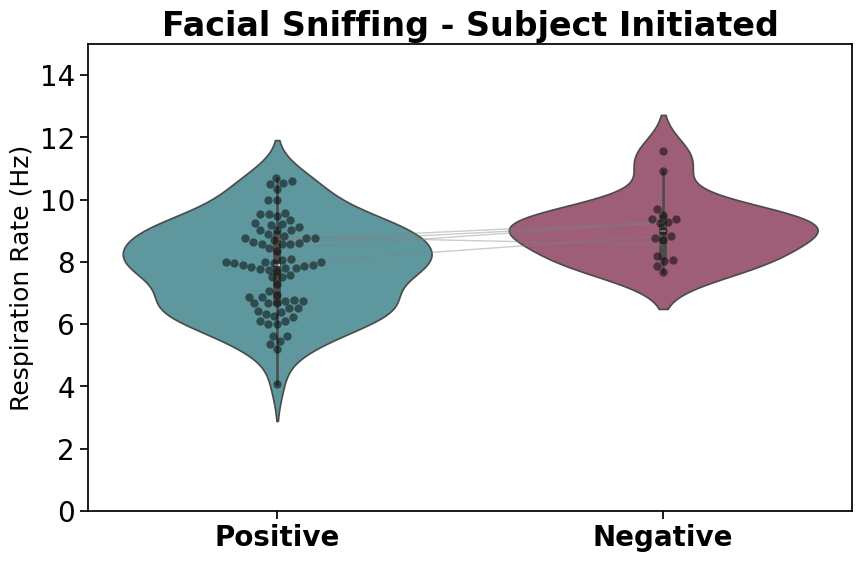

C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


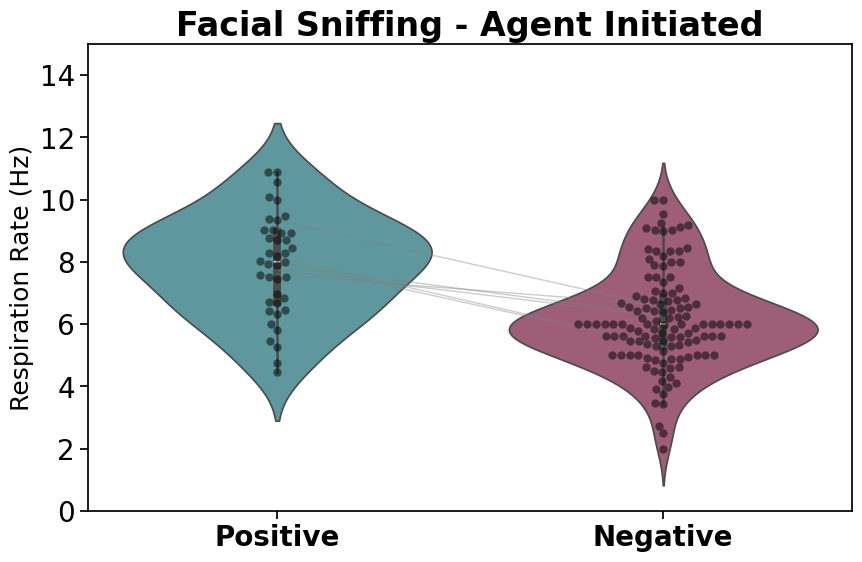

C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


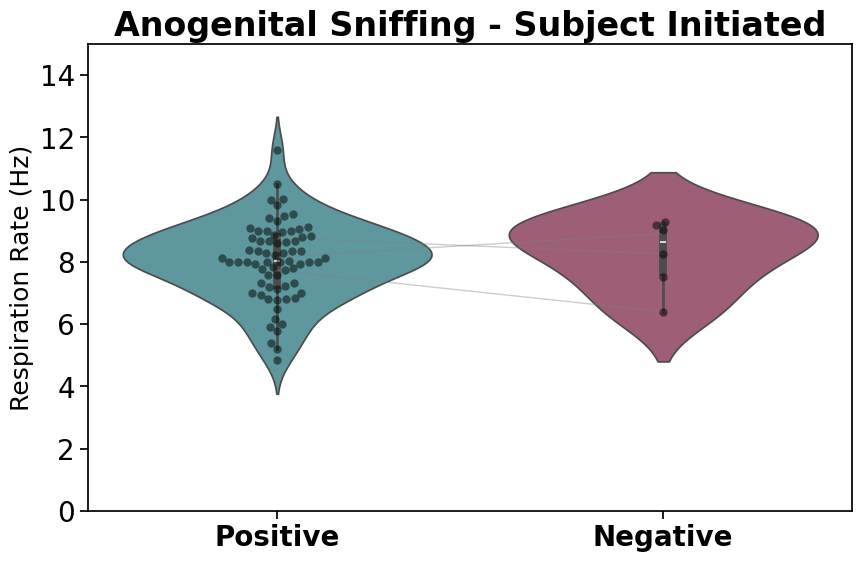

C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


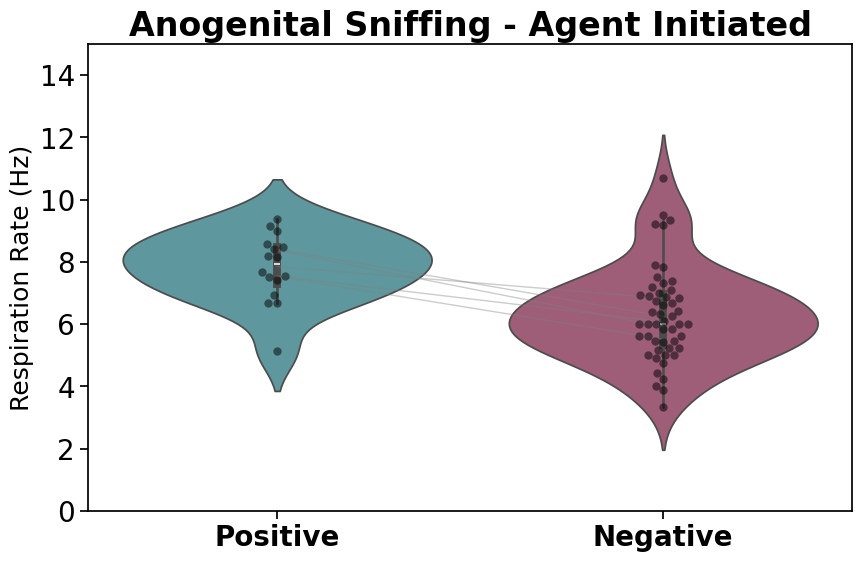

C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


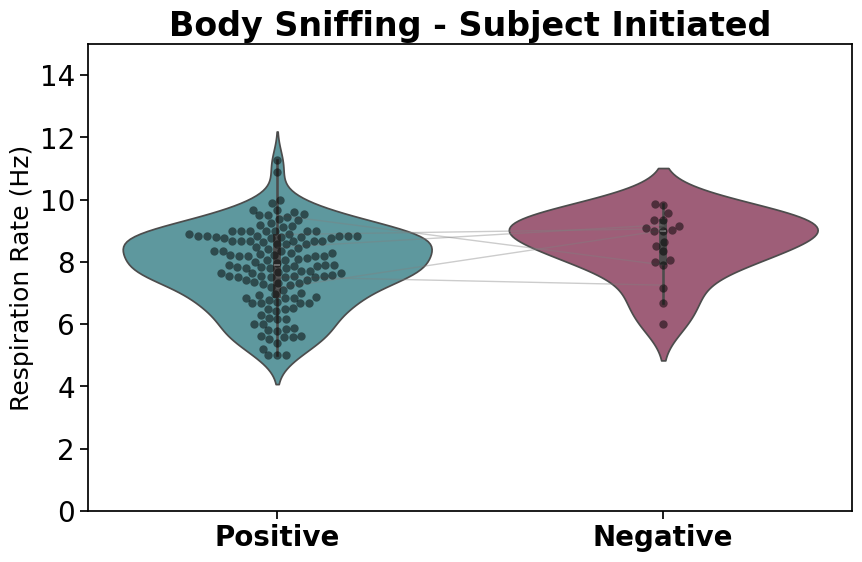

C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\3946194150.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


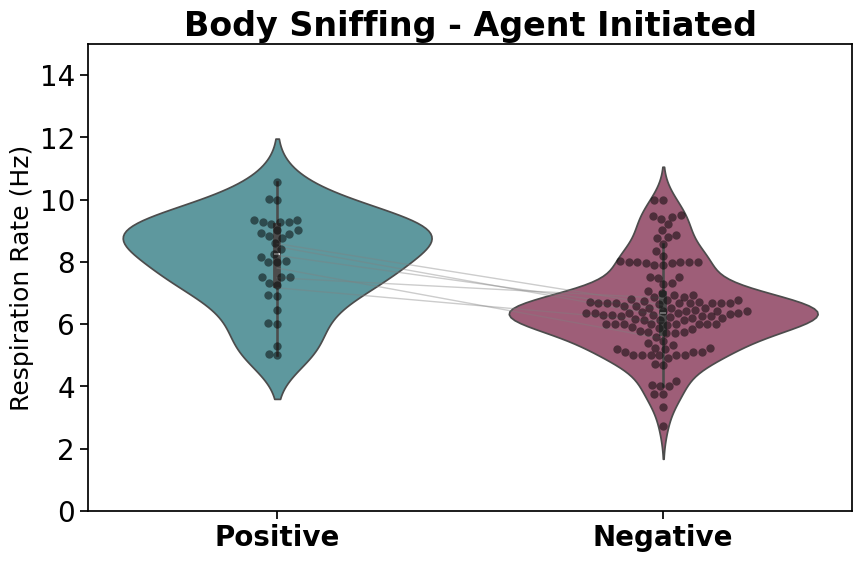

In [ ]:
plot_behavior_by_initiator_valence('Facial Sniffing')
plot_behavior_by_initiator_valence('Anogenital Sniffing')
plot_behavior_by_initiator_valence('Body Sniffing')

In [ ]:
def plot_all_behaviors_subject_level_boxplot(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    behaviors = ['Facial Sniffing', 'Body Sniffing', 'Anogenital Sniffing']
    palette = {'Positive': '#53A1A9', 'Negative': '#A95376'}
    valence_order = ['Positive', 'Negative']

    # assign each subject a unique color
    subject_ids = df['Subject_ID'].unique()
    subject_palette = sns.color_palette("tab20", len(subject_ids))
    subj_color_map = dict(zip(subject_ids, subject_palette))
    total_subjects = len(subject_ids)

    for behavior_name in behaviors:
        # --- Filter + aggregate ---
        subset = df[df['Behavior'].str.lower() == behavior_name.lower()].copy()

        agg_df = (
            subset.groupby(['Subject_ID', 'Valence', 'Initiator'])['Respiration Rate (Hz)']
            .mean()
            .reset_index()
        )

        # --- Helper to plot one panel ---
        def plot_panel(data, title_suffix):
            included_subj = data['Subject_ID'].nunique()
            missing_subj = sorted(set(subject_ids) - set(data['Subject_ID']))
            print(f"{behavior_name} - {title_suffix}: {included_subj}/{total_subjects} subjects contributed")
            if missing_subj:
                print("   Missing:", ", ".join(missing_subj))

            plt.figure(figsize=(9, 6))

            # Background boxplot
            sns.boxplot(
                x='Valence', y='Respiration Rate (Hz)', data=data,
                order=valence_order, palette=palette, showfliers=False
            )

            # Jittered subject points (colored by subject)
            for subj, subj_data in data.groupby('Subject_ID'):
                sns.stripplot(
                    x='Valence', y='Respiration Rate (Hz)', data=subj_data,
                    order=valence_order, color=subj_color_map[subj],
                    size=8, jitter=0.15, edgecolor='k', linewidth=0.5, zorder=5, label=subj
                )

            # Legend (unique subjects)
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.legend(by_label.values(), by_label.keys(),
                       bbox_to_anchor=(1.05, 1), loc='upper left', title="Subject")

            plt.title(f'{behavior_name} - {title_suffix}', fontsize=24, fontweight='bold')
            plt.ylim(0, 15)
            plt.ylabel('Respiration Rate (Hz)', fontsize=18)
            plt.xlabel('')
            plt.xticks([0, 1], valence_order, fontsize=20, fontweight='bold')
            plt.yticks(fontsize=20)
            plt.tight_layout()
            plt.show()

        # --- Generate two panels for this behavior ---
        plot_panel(agg_df[agg_df['Initiator'] == 'Subject'], 'Subject Initiated')
        plot_panel(agg_df[agg_df['Initiator'] == 'Agent'], 'Agent Initiated')



In [ ]:
subj_counts = final_df['Subject_ID'].value_counts()
print(subj_counts)


Subject_ID
3_6    26
2_3    24
2_4    21
4_8    21
1_2    19
4_7    19
1_1    18
3_5    10
Name: count, dtype: int64


In [ ]:
def plot_all_behaviors_subject_level_boxplot(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    behaviors = ['Facial Sniffing', 'Body Sniffing', 'Anogenital Sniffing']
    palette = {'Positive': '#53A1A9', 'Negative': '#A95376'}
    valence_order = ['Positive', 'Negative']

    # assign each subject a unique color
    subject_ids = df['Subject_ID'].unique()
    subject_palette = sns.color_palette("tab20", len(subject_ids))
    subj_color_map = dict(zip(subject_ids, subject_palette))
    total_subjects = len(subject_ids)

    for behavior_name in behaviors:
        # --- Filter + aggregate ---
        subset = df[df['Behavior'].str.lower() == behavior_name.lower()].copy()

        agg_df = (
            subset.groupby(['Subject_ID', 'Valence', 'Initiator'])['Respiration Rate (Hz)']
            .mean()
            .reset_index()
        )

        # --- Helper to plot one panel ---
        def plot_panel(data, title_suffix):
            included_subj = data['Subject_ID'].nunique()

            # subjects with both valences vs. single
            subj_valence_counts = data.groupby('Subject_ID')['Valence'].nunique()
            both_valences = subj_valence_counts[subj_valence_counts == 2].index.tolist()
            single_valence = subj_valence_counts[subj_valence_counts == 1].index.tolist()

            print(f"{behavior_name} - {title_suffix}: {included_subj}/{total_subjects} subjects contributed")
            print(f"   {len(both_valences)} subjects had BOTH Positive & Negative: {both_valences}")
            print(f"   {len(single_valence)} subjects had ONLY one valence: {single_valence}")

            plt.figure(figsize=(9, 6))

            # Background boxplot (with explicit hue to silence warning)
            sns.boxplot(
                x='Valence', y='Respiration Rate (Hz)', data=data,
                order=valence_order, palette=palette, showfliers=False,
                hue='Valence', dodge=False, legend=False
            )

            # Jittered subject points
            for subj, subj_data in data.groupby('Subject_ID'):
                sns.stripplot(
                    x='Valence', y='Respiration Rate (Hz)', data=subj_data,
                    order=valence_order, color=subj_color_map[subj],
                    size=8, jitter=0.15, edgecolor='k', linewidth=0.5,
                    zorder=5, label=subj
                )

            # Legend (unique subjects)
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.legend(by_label.values(), by_label.keys(),
                       bbox_to_anchor=(1.05, 1), loc='upper left', title="Subject")

            plt.title(f'{behavior_name} - {title_suffix}', fontsize=24, fontweight='bold')
            plt.ylim(0, 15)
            plt.ylabel('Respiration Rate (Hz)', fontsize=18)
            plt.xlabel('')
            plt.xticks([0, 1], valence_order, fontsize=20, fontweight='bold')
            plt.yticks(fontsize=20)
            plt.tight_layout()
            plt.show()

        # --- Generate two panels for this behavior ---
        plot_panel(agg_df[agg_df['Initiator'] == 'Subject'], 'Subject Initiated')
        plot_panel(agg_df[agg_df['Initiator'] == 'Agent'], 'Agent Initiated')


Facial Sniffing - Subject Initiated: 8/8 subjects contributed
   7 subjects had BOTH Positive & Negative: ['1_1', '1_2', '2_3', '2_4', '3_6', '4_7', '4_8']
   1 subjects had ONLY one valence: ['3_5']


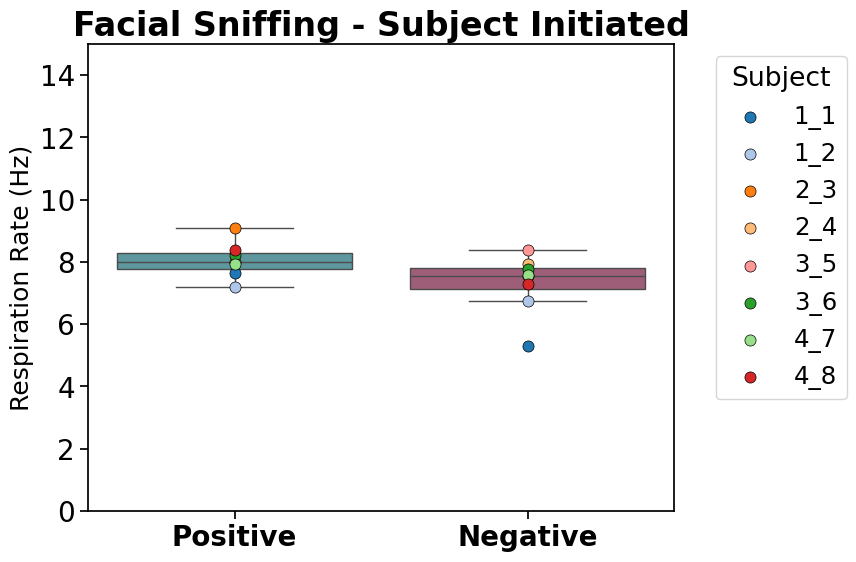

Facial Sniffing - Agent Initiated: 8/8 subjects contributed
   6 subjects had BOTH Positive & Negative: ['1_1', '2_3', '2_4', '3_6', '4_7', '4_8']
   2 subjects had ONLY one valence: ['1_2', '3_5']


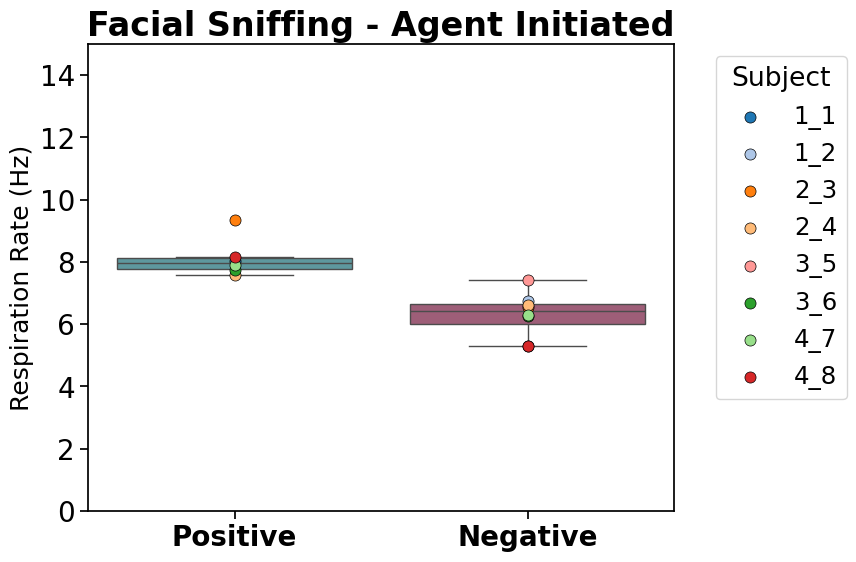

Body Sniffing - Subject Initiated: 8/8 subjects contributed
   7 subjects had BOTH Positive & Negative: ['1_1', '1_2', '2_3', '2_4', '3_6', '4_7', '4_8']
   1 subjects had ONLY one valence: ['3_5']


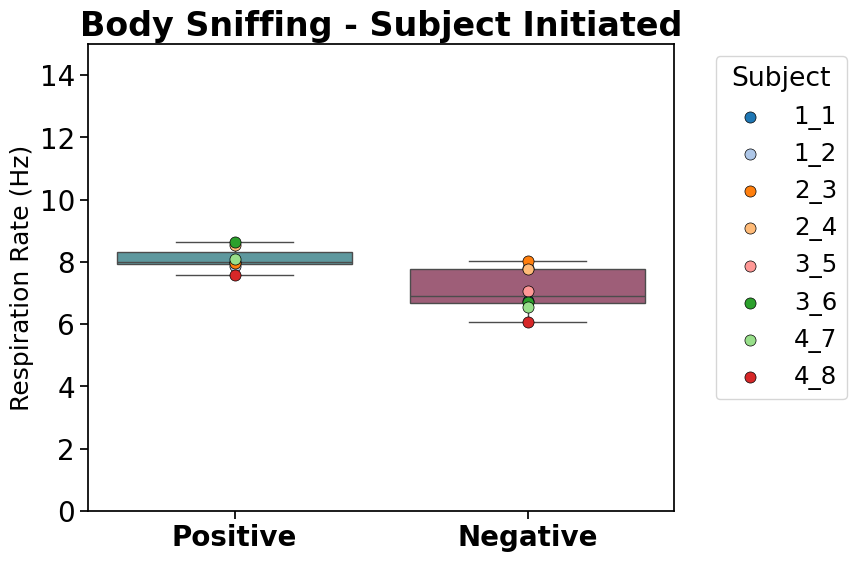

Body Sniffing - Agent Initiated: 8/8 subjects contributed
   6 subjects had BOTH Positive & Negative: ['1_1', '1_2', '2_3', '2_4', '3_6', '4_8']
   2 subjects had ONLY one valence: ['3_5', '4_7']


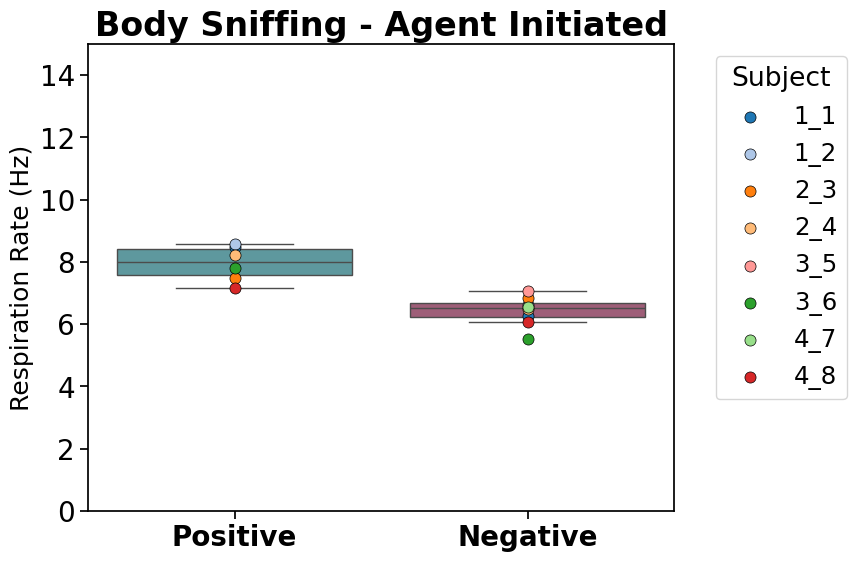

Anogenital Sniffing - Subject Initiated: 7/8 subjects contributed
   7 subjects had BOTH Positive & Negative: ['1_1', '1_2', '2_3', '2_4', '3_6', '4_7', '4_8']
   0 subjects had ONLY one valence: []


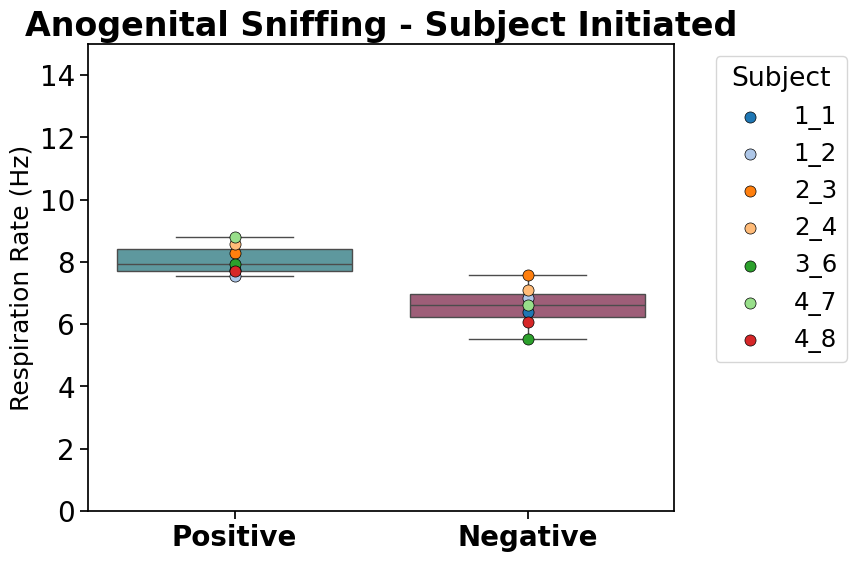

Anogenital Sniffing - Agent Initiated: 6/8 subjects contributed
   5 subjects had BOTH Positive & Negative: ['1_2', '2_3', '2_4', '3_6', '4_8']
   1 subjects had ONLY one valence: ['4_7']


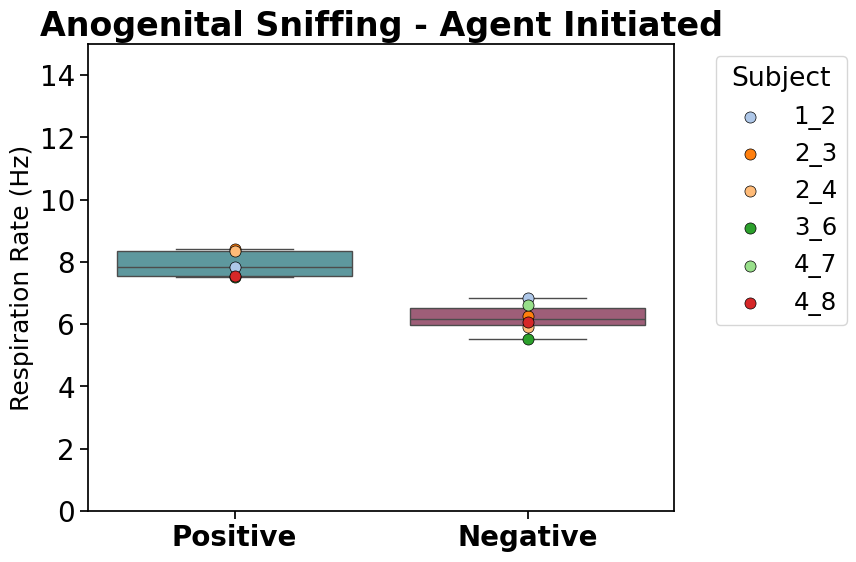

In [ ]:
plot_all_behaviors_subject_level_boxplot(final_df)

In [ ]:
full_df


,Trial,Subject,Behavior,Start (s),Stop (s),Duration (s),Respiration Rate (Hz),Valence,Initiator,SubjectID
1,RI1_3_6,subject,facial sniffing,11.966,13.000,1.034,6.769826,Positive,Subject,3_6
3,RI1_3_6,subject,anogenital sniffing,14.483,16.690,2.207,8.608971,Positive,Subject,3_6
4,RI1_3_6,subject,anogenital sniffing,19.069,19.483,0.414,4.830918,Positive,Subject,3_6
5,RI1_3_6,subject,anogenital sniffing,21.379,21.724,0.345,11.594203,Positive,Subject,3_6
6,RI1_3_6,subject,anogenital sniffing,25.034,27.552,2.518,8.339952,Positive,Subject,3_6
7,RI1_3_6,subject,body sniffing,27.793,28.448,0.655,9.160305,Positive,Subject,3_6
8,RI1_3_6,subject,anogenital sniffing,28.862,29.861,0.999,8.008008,Positive,Subject,3_6
9,RI1_3_6,subject,body sniffing,29.862,30.586,0.724,9.668508,Positive,Subject,3_6
10,RI1_3_6,subject,anogenital sniffing,33.552,36.069,2.517,9.535161,Positive,Subject,3_6
11,RI1_3_6,subject,anogenital sniffing,40.759,41.792,1.033,6.776379,Positive,Subject,3_6


In [ ]:
def plot_paired_behavior(behavior_name, initiator_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Prepare and combine data with valence and initiator labels (same as before)
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior', 'Trial', 'Respiration Rate (Hz)'])

    # Extract SubjectID from Trial (reuse your function)
    def extract_subject(trial_str):
        parts = trial_str.split('_')
        if len(parts) >= 3:
            return parts[-2] + '_' + parts[-1]
        else:
            return None
    full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

    # Clean behavior labels
    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map).fillna(full_df['Behavior'])

    # Filter for behavior and initiator
    df = full_df[(full_df['Behavior'] == behavior_name) & (full_df['Initiator'] == initiator_name)]

    # Aggregate respiration rate per subject and valence
    agg_df = df.groupby(['SubjectID', 'Valence'])['Respiration Rate (Hz)'].mean().reset_index()


    # Pivot so Positive and Negative are columns for each SubjectID
    paired = agg_df.pivot(index='SubjectID', columns='Valence', values='Respiration Rate (Hz)').dropna()

    # Plot paired data
    plt.figure(figsize=(6,6))
    plt.title(f'{behavior_name} - {initiator_name} Initiated (Paired)', fontsize=16, fontweight='bold')
    plt.ylabel('Respiration Rate (Hz)', fontsize=14)
    plt.xticks([0,1], ['Positive', 'Negative'], fontsize=14, fontweight='bold')
    plt.ylim(0, 15)

    # Plot points for each subject and connect pairs with a line
    for subject in paired.index:
        plt.plot([0,1], paired.loc[subject, ['Positive', 'Negative']], marker='o', color='gray', alpha=0.6)

    # Also plot summary points (means)
    means = paired.mean()
    plt.scatter([0,1], means, color='red', s=100, label='Mean', zorder=5)
    plt.legend()

    plt.tight_layout()
    plt.show()


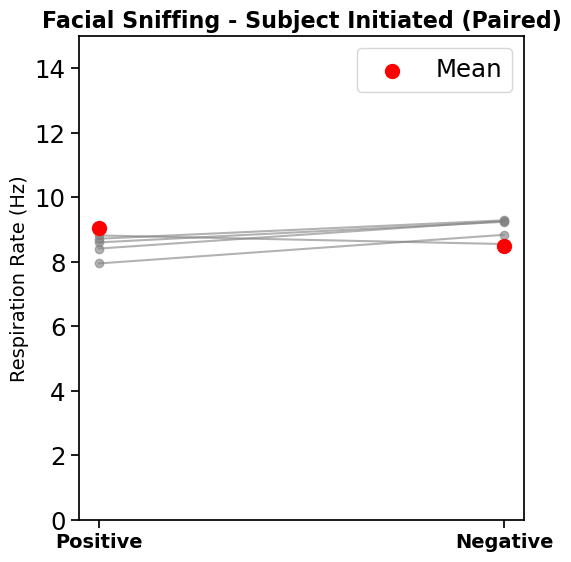

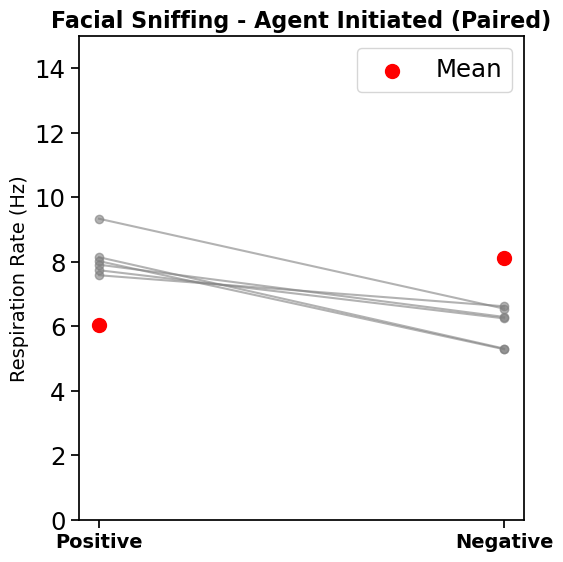

In [ ]:
plot_paired_behavior('Facial Sniffing', 'Subject')
plot_paired_behavior('Facial Sniffing', 'Agent')


In [ ]:
# Step 1: Create full_df as before
pos_subject_df_labeled = pos_subject_df.copy()
pos_subject_df_labeled['Valence'] = 'Positive'
pos_subject_df_labeled['Initiator'] = 'Subject'

neg_subject_df_labeled = neg_subject_df.copy()
neg_subject_df_labeled['Valence'] = 'Negative'
neg_subject_df_labeled['Initiator'] = 'Subject'

pos_agent_df_labeled = pos_agent_df.copy()
pos_agent_df_labeled['Valence'] = 'Positive'
pos_agent_df_labeled['Initiator'] = 'Agent'

neg_agent_df_labeled = neg_agent_df.copy()
neg_agent_df_labeled['Valence'] = 'Negative'
neg_agent_df_labeled['Initiator'] = 'Agent'

full_df = pd.concat([
    pos_subject_df_labeled,
    neg_subject_df_labeled,
    pos_agent_df_labeled,
    neg_agent_df_labeled
]).dropna(subset=['Behavior'])

# --- Insert your SubjectID extraction here ---
def extract_subject(trial_str):
    parts = trial_str.split('_')
    if len(parts) >= 3:
        return parts[-2] + '_' + parts[-1]
    else:
        return None

full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

# Now you have full_df with a proper SubjectID column to use for pairing!


In [ ]:
print("✅ pos_subject_df:")
print(pos_subject_df.columns)
print(pos_subject_df.head())
print()

print("✅ neg_subject_df:")
print(neg_subject_df.columns)
print(neg_subject_df.head())
print()

print("✅ pos_agent_df:")
print(pos_agent_df.columns)
print(pos_agent_df.head())
print()

print("✅ neg_agent_df:")
print(neg_agent_df.columns)
print(neg_agent_df.head())


✅ pos_subject_df:
Index(['Trial', 'Subject', 'Behavior', 'Start (s)', 'Stop (s)', 'Duration (s)',
       'Respiration Rate (Hz)', 'Valence'],
      dtype='object')
     Trial  Subject             Behavior  Start (s)  Stop (s)  Duration (s)  \
1  RI1_3_6  subject      facial sniffing     11.966    13.000         1.034   
3  RI1_3_6  subject  anogenital sniffing     14.483    16.690         2.207   
4  RI1_3_6  subject  anogenital sniffing     19.069    19.483         0.414   
5  RI1_3_6  subject  anogenital sniffing     21.379    21.724         0.345   
6  RI1_3_6  subject  anogenital sniffing     25.034    27.552         2.518   

   Respiration Rate (Hz)                      Valence  
1               6.769826  Positive Social Interaction  
3               8.608971  Positive Social Interaction  
4               4.830918  Positive Social Interaction  
5              11.594203  Positive Social Interaction  
6               8.339952  Positive Social Interaction  

✅ neg_subject_df:
Index(

In [ ]:
print(pos_subject_df['Subject'].unique())
print(neg_subject_df['Subject'].unique())
print(pos_agent_df['Subject'].unique())
print(neg_agent_df['Subject'].unique())


['subject']
['subject']
['social_agent']
['social_agent']


In [ ]:
print("Missing Behaviors:", pd.concat([
    pos_subject_df_labeled, neg_subject_df_labeled,
    pos_agent_df_labeled, neg_agent_df_labeled
])['Behavior'].isna().sum())

print("Missing Trials:", pd.concat([
    pos_subject_df_labeled, neg_subject_df_labeled,
    pos_agent_df_labeled, neg_agent_df_labeled
])['Trial'].isna().sum())

print("Missing Resp Rate:", pd.concat([
    pos_subject_df_labeled, neg_subject_df_labeled,
    pos_agent_df_labeled, neg_agent_df_labeled
])['Respiration Rate (Hz)'].isna().sum())


Missing Behaviors: 0
Missing Trials: 0
Missing Resp Rate: 0


In [ ]:
print(full_df['Behavior'].value_counts(dropna=False))


Behavior
body sniffing          319
facial sniffing        258
anogenital sniffing    143
fighting               114
Posturing               66
chasing                 27
tails rattling           5
Name: count, dtype: int64


In [ ]:
full_df

,Trial,Subject,Behavior,Start (s),Stop (s),Duration (s),Respiration Rate (Hz),Valence,Initiator,SubjectID
1,RI1_3_6,subject,facial sniffing,11.966,13.000,1.034,6.769826,Positive,Subject,3_6
3,RI1_3_6,subject,anogenital sniffing,14.483,16.690,2.207,8.608971,Positive,Subject,3_6
4,RI1_3_6,subject,anogenital sniffing,19.069,19.483,0.414,4.830918,Positive,Subject,3_6
5,RI1_3_6,subject,anogenital sniffing,21.379,21.724,0.345,11.594203,Positive,Subject,3_6
6,RI1_3_6,subject,anogenital sniffing,25.034,27.552,2.518,8.339952,Positive,Subject,3_6
7,RI1_3_6,subject,body sniffing,27.793,28.448,0.655,9.160305,Positive,Subject,3_6
8,RI1_3_6,subject,anogenital sniffing,28.862,29.861,0.999,8.008008,Positive,Subject,3_6
9,RI1_3_6,subject,body sniffing,29.862,30.586,0.724,9.668508,Positive,Subject,3_6
10,RI1_3_6,subject,anogenital sniffing,33.552,36.069,2.517,9.535161,Positive,Subject,3_6
11,RI1_3_6,subject,anogenital sniffing,40.759,41.792,1.033,6.776379,Positive,Subject,3_6


In [ ]:
def run_wilcoxon_on_aggregated_with_subjectid(behavior_name, initiator_name):
    # 1. Combine and label dataframes
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior', 'Trial', 'Respiration Rate (Hz)'])

    # 2. Extract SubjectID from Trial
    def extract_subject(trial_str):
        parts = trial_str.split('_')
        if len(parts) >= 3:
            return parts[-2] + '_' + parts[-1]
        else:
            return None

    full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

    # 3. Clean and map behavior names
    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map).fillna(full_df['Behavior'])

    # 4. Filter for behavior and initiator
    df = full_df[(full_df['Behavior'] == behavior_name) & (full_df['Initiator'] == initiator_name)]

    # 5. Aggregate respiration rate per mouse, valence
    agg_df = df.groupby(['SubjectID', 'Valence'])['Respiration Rate (Hz)'].mean().reset_index()

    # 6. Prepare paired dataframes for Positive and Negative respiration rates
    pos_data = agg_df[agg_df['Valence'] == 'Positive'][['SubjectID', 'Respiration Rate (Hz)']].set_index('SubjectID')
    neg_data = agg_df[agg_df['Valence'] == 'Negative'][['SubjectID', 'Respiration Rate (Hz)']].set_index('SubjectID')

    # 7. Join paired data and drop missing pairs
    paired = pos_data.join(neg_data, lsuffix='_pos', rsuffix='_neg').dropna()

    # 8. Run Wilcoxon signed-rank test
    stat, p = wilcoxon(paired['Respiration Rate (Hz)_pos'], paired['Respiration Rate (Hz)_neg'])

    # 9. Print results
    print(f"Wilcoxon signed-rank test for {behavior_name} - {initiator_name} (aggregated by SubjectID):")
    print(f"Statistic = {stat:.3f}, p-value = {p:.4f}")
    print(f"Number of pairs = {len(paired)}")

    return stat, p


In [ ]:
#print(pos_subject_df['Trial'].unique())
print(neg_subject_df['Trial'].unique())


NameError: name 'neg_subject_df' is not defined

In [ ]:
#print(pos_subject_df['Trial'].unique())
print(pos_subject_df['Trial'].unique())

NameError: name 'pos_subject_df' is not defined

In [ ]:
run_wilcoxon_on_aggregated_with_subjectid('Facial Sniffing', 'Subject')
run_wilcoxon_on_aggregated_with_subjectid('Facial Sniffing', 'Agent')



Wilcoxon signed-rank test for Facial Sniffing - Subject (aggregated by SubjectID):
Statistic = 1.000, p-value = 0.1250
Number of pairs = 5
Wilcoxon signed-rank test for Facial Sniffing - Agent (aggregated by SubjectID):
Statistic = 0.000, p-value = 0.0312
Number of pairs = 6


(0.0, 0.03125)

In [ ]:
# Define the behaviors and initiators you want to test
behaviors = ['Facial Sniffing', 'Body Sniffing', 'Anogenital Sniffing']
initiators = ['Subject', 'Agent']

# Run Wilcoxon for each combination
results = []

for behavior in behaviors:
    for initiator in initiators:
        print(f"Running test for: {behavior} - {initiator}")
        stat, p = run_wilcoxon_on_aggregated_with_subjectid(behavior, initiator)
        results.append({
            'Behavior': behavior,
            'Initiator': initiator,
            'Statistic': stat,
            'p-value': p
        })


Running test for: Facial Sniffing - Subject
Wilcoxon signed-rank test for Facial Sniffing - Subject (aggregated by SubjectID):
Statistic = 1.000, p-value = 0.1250
Number of pairs = 5
Running test for: Facial Sniffing - Agent
Wilcoxon signed-rank test for Facial Sniffing - Agent (aggregated by SubjectID):
Statistic = 0.000, p-value = 0.0312
Number of pairs = 6
Running test for: Body Sniffing - Subject
Wilcoxon signed-rank test for Body Sniffing - Subject (aggregated by SubjectID):
Statistic = 6.000, p-value = 0.8125
Number of pairs = 5
Running test for: Body Sniffing - Agent
Wilcoxon signed-rank test for Body Sniffing - Agent (aggregated by SubjectID):
Statistic = 0.000, p-value = 0.0312
Number of pairs = 6
Running test for: Anogenital Sniffing - Subject
Wilcoxon signed-rank test for Anogenital Sniffing - Subject (aggregated by SubjectID):
Statistic = 2.000, p-value = 0.7500
Number of pairs = 3
Running test for: Anogenital Sniffing - Agent
Wilcoxon signed-rank test for Anogenital Sniffi

In [ ]:
from scipy.stats import ttest_rel

def run_ttest_on_aggregated_with_subjectid(behavior_name, initiator_name):
    # 1–7: Same as your existing code
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior', 'Trial', 'Respiration Rate (Hz)'])

    def extract_subject(trial_str):
        parts = trial_str.split('_')
        if len(parts) >= 3:
            return parts[-2] + '_' + parts[-1]
        else:
            return None

    full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map).fillna(full_df['Behavior'])

    df = full_df[(full_df['Behavior'] == behavior_name) & (full_df['Initiator'] == initiator_name)]

    agg_df = df.groupby(['SubjectID', 'Valence'])['Respiration Rate (Hz)'].mean().reset_index()

    pos_data = agg_df[agg_df['Valence'] == 'Positive'][['SubjectID', 'Respiration Rate (Hz)']].set_index('SubjectID')
    neg_data = agg_df[agg_df['Valence'] == 'Negative'][['SubjectID', 'Respiration Rate (Hz)']].set_index('SubjectID')

    paired = pos_data.join(neg_data, lsuffix='_pos', rsuffix='_neg').dropna()

    # 🔹 Paired t-test
    t_stat, p = ttest_rel(paired['Respiration Rate (Hz)_pos'], paired['Respiration Rate (Hz)_neg'])

    print(f"Paired t-test for {behavior_name} - {initiator_name} (aggregated by SubjectID):")
    print(f"t = {t_stat:.3f}, p = {p:.4f}, df = {len(paired)-1}")
    print(f"Number of pairs = {len(paired)}")

    return t_stat, p


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

# Custom palette
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),  # teal
    'Negative': (169/255, 83/255, 118/255)   # magenta
}

def run_ttest_and_plot(behavior_name, initiator_name):
    # 1. Label dataframes
    pos_subject_df_labeled = pos_subject_df.copy()
    pos_subject_df_labeled['Valence'] = 'Positive'
    pos_subject_df_labeled['Initiator'] = 'Subject'

    neg_subject_df_labeled = neg_subject_df.copy()
    neg_subject_df_labeled['Valence'] = 'Negative'
    neg_subject_df_labeled['Initiator'] = 'Subject'

    pos_agent_df_labeled = pos_agent_df.copy()
    pos_agent_df_labeled['Valence'] = 'Positive'
    pos_agent_df_labeled['Initiator'] = 'Agent'

    neg_agent_df_labeled = neg_agent_df.copy()
    neg_agent_df_labeled['Valence'] = 'Negative'
    neg_agent_df_labeled['Initiator'] = 'Agent'

    full_df = pd.concat([
        pos_subject_df_labeled,
        neg_subject_df_labeled,
        pos_agent_df_labeled,
        neg_agent_df_labeled
    ]).dropna(subset=['Behavior', 'Trial', 'Respiration Rate (Hz)'])

    # 2. Extract SubjectID
    def extract_subject(trial_str):
        parts = trial_str.split('_')
        if len(parts) >= 3:
            return parts[-2] + '_' + parts[-1]
        else:
            return None

    full_df['SubjectID'] = full_df['Trial'].apply(extract_subject)

    # 3. Clean behavior names
    full_df['Behavior'] = full_df['Behavior'].str.strip().str.lower()
    behavior_label_map = {
        'facial sniffing': 'Facial Sniffing',
        'anogenital sniffing': 'Anogenital Sniffing',
        'body sniffing': 'Body Sniffing'
    }
    full_df['Behavior'] = full_df['Behavior'].map(behavior_label_map).fillna(full_df['Behavior'])

    # 4. Filter for behavior × initiator
    df = full_df[(full_df['Behavior'] == behavior_name) & (full_df['Initiator'] == initiator_name)]

    # 5. Aggregate per subject × valence
    agg_df = df.groupby(['SubjectID', 'Valence'])['Respiration Rate (Hz)'].mean().reset_index()

    # 6. Pair positive vs negative per subject
    pos_data = agg_df[agg_df['Valence'] == 'Positive'][['SubjectID', 'Respiration Rate (Hz)']].set_index('SubjectID')
    neg_data = agg_df[agg_df['Valence'] == 'Negative'][['SubjectID', 'Respiration Rate (Hz)']].set_index('SubjectID')

    paired = pos_data.join(neg_data, lsuffix='_pos', rsuffix='_neg').dropna()

    # 7. Paired t-test
    t_stat, p = ttest_rel(paired['Respiration Rate (Hz)_pos'], paired['Respiration Rate (Hz)_neg'])

    print(f"Paired t-test for {behavior_name} - {initiator_name} (aggregated by SubjectID):")
    print(f"t = {t_stat:.3f}, p = {p:.4f}, df = {len(paired)-1}")
    print(f"Number of pairs = {len(paired)}")

    # 8. Plot paired lines
    plt.figure(figsize=(8,6))
    sns.set_context("notebook", font_scale=1.4)

    for sid, row in paired.iterrows():
        plt.plot(['Positive', 'Negative'],
                 [row['Respiration Rate (Hz)_pos'], row['Respiration Rate (Hz)_neg']],
                 marker='o', color='gray', alpha=0.7, linewidth=1.5)

    # Overlay group means
    sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
                  palette=custom_palette, ci=68, join=False,
                  markers="_", scale=1.5)

    plt.title(f"{behavior_name} – {initiator_name}", fontsize=20, weight="bold")
    plt.ylabel("Respiration Rate (Hz)", fontsize=16, weight="bold")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

    return t_stat, p


In [ ]:
# Example: Facial sniffing – Agent initiated
df = full_df[
    (full_df["Behavior"] == "facial sniffing") &
    (full_df["Initiator"] == "Agent")   # check if it's 'Agent' or 'agent'
]

# Count bouts per Subject × Valence
bout_counts = (
    df.groupby(["SubjectID", "Valence"])
    .size()
    .reset_index(name="Bout_Count")
)

print(bout_counts)



   SubjectID   Valence  Bout_Count
0        1_1  Negative           3
1        1_1  Positive           1
2        1_2  Negative          16
3        2_3  Negative          11
4        2_3  Positive           1
5        2_4  Negative          13
6        2_4  Positive           7
7        3_5  Negative           4
8        3_6  Negative          25
9        3_6  Positive          14
10       4_7  Negative          18
11       4_7  Positive           6
12       4_8  Negative          32
13       4_8  Positive          11


In [ ]:
agg_with_counts = (
    df.groupby(["SubjectID", "Valence"])
    .agg(
        Resp_Mean=("Respiration Rate (Hz)", "mean"),
        Bout_Count=("Respiration Rate (Hz)", "size")
    )
    .reset_index()
)

print(agg_with_counts)


   SubjectID   Valence  Resp_Mean  Bout_Count
0        1_1  Negative   5.287463           3
1        1_1  Positive   8.019246           1
2        1_2  Negative   6.725760          16
3        2_3  Negative   6.545701          11
4        2_3  Positive   9.333333           1
5        2_4  Negative   6.619235          13
6        2_4  Positive   7.581343           7
7        3_5  Negative   7.407305           4
8        3_6  Negative   6.244289          25
9        3_6  Positive   7.737239          14
10       4_7  Negative   6.288799          18
11       4_7  Positive   7.908156           6
12       4_8  Negative   5.307621          32
13       4_8  Positive   8.141209          11



Running paired t-test for: Facial Sniffing - Subject
Paired t-test for Facial Sniffing - Subject (aggregated by SubjectID):
t = -2.556, p = 0.0629, df = 4
Number of pairs = 5


C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `join` param

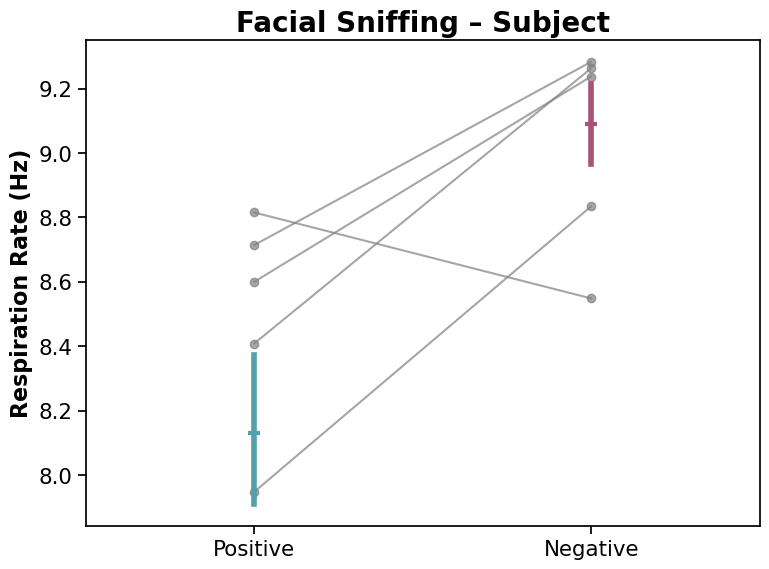


Running paired t-test for: Facial Sniffing - Agent
Paired t-test for Facial Sniffing - Agent (aggregated by SubjectID):
t = 6.245, p = 0.0015, df = 5
Number of pairs = 6


C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `join` param

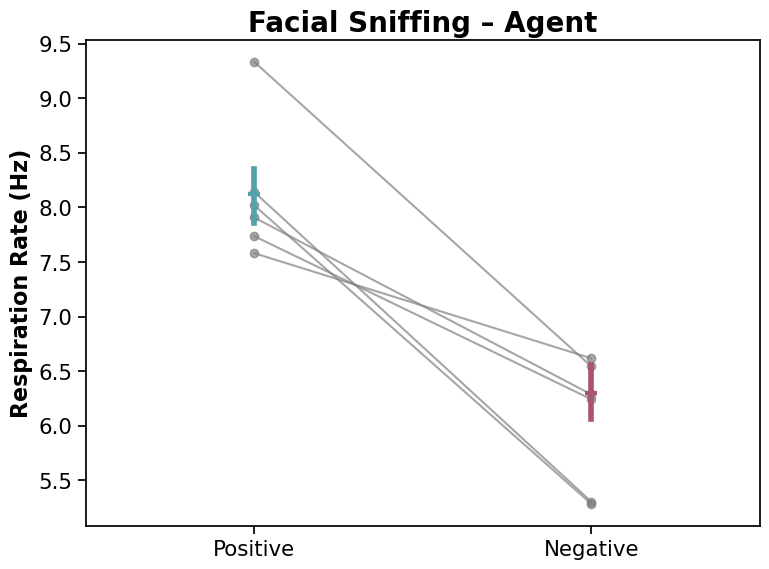


Running paired t-test for: Body Sniffing - Subject
Paired t-test for Body Sniffing - Subject (aggregated by SubjectID):
t = -0.315, p = 0.7682, df = 4
Number of pairs = 5


C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `join` param

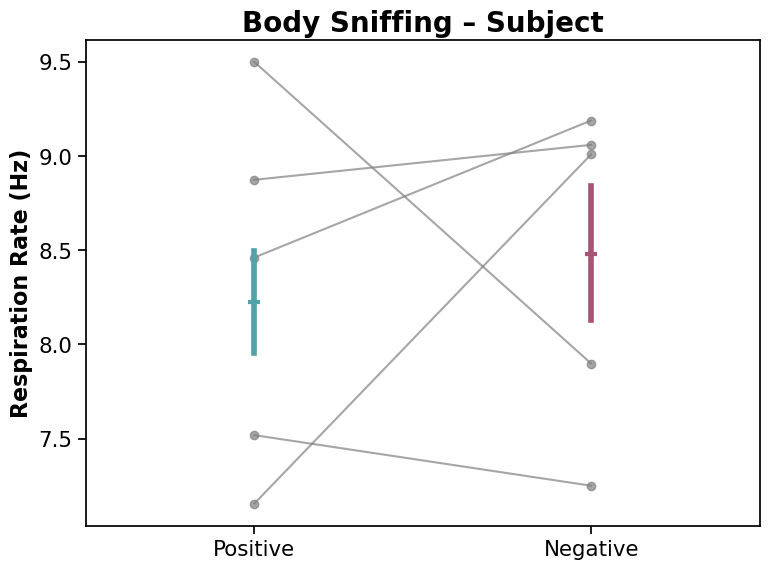


Running paired t-test for: Body Sniffing - Agent
Paired t-test for Body Sniffing - Agent (aggregated by SubjectID):
t = 6.202, p = 0.0016, df = 5
Number of pairs = 6


C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `join` param

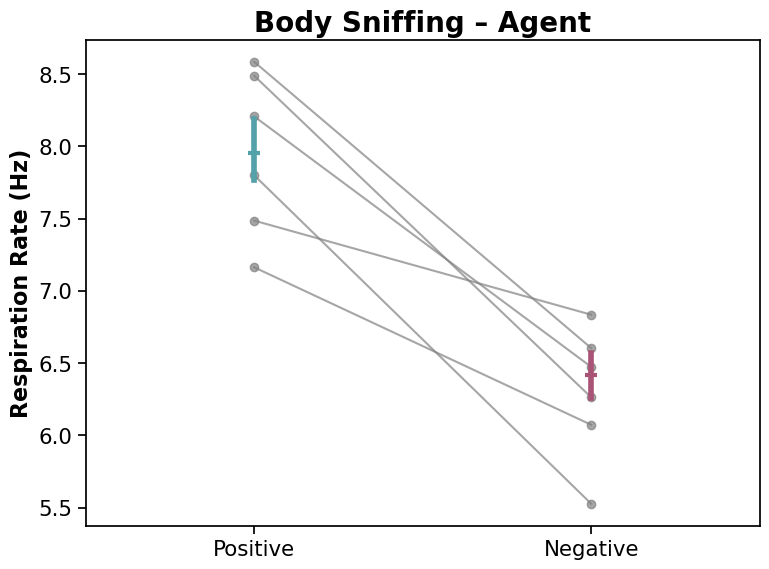


Running paired t-test for: Anogenital Sniffing - Subject
Paired t-test for Anogenital Sniffing - Subject (aggregated by SubjectID):
t = 0.607, p = 0.6057, df = 2
Number of pairs = 3


C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `join` param

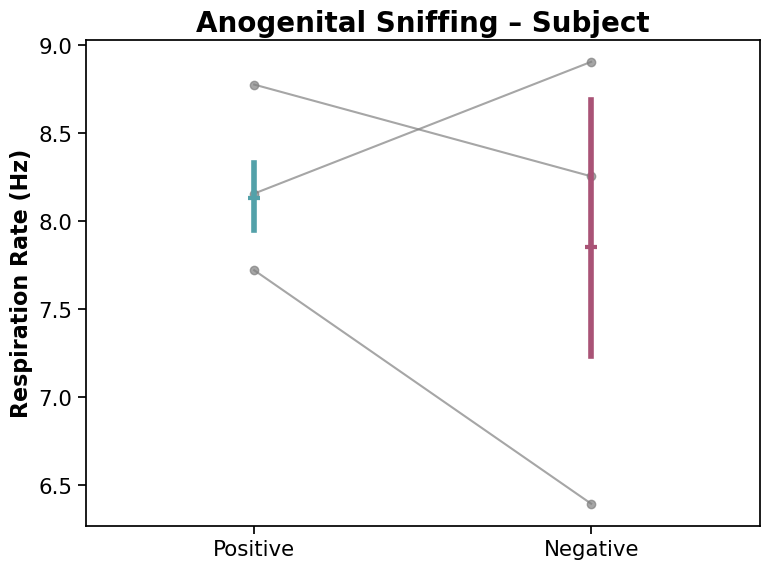


Running paired t-test for: Anogenital Sniffing - Agent
Paired t-test for Anogenital Sniffing - Agent (aggregated by SubjectID):
t = 7.128, p = 0.0020, df = 4
Number of pairs = 5


C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
C:\Users\sjs93\AppData\Local\Temp\ipykernel_31608\996205987.py:85: UserWarning: 

The `join` param

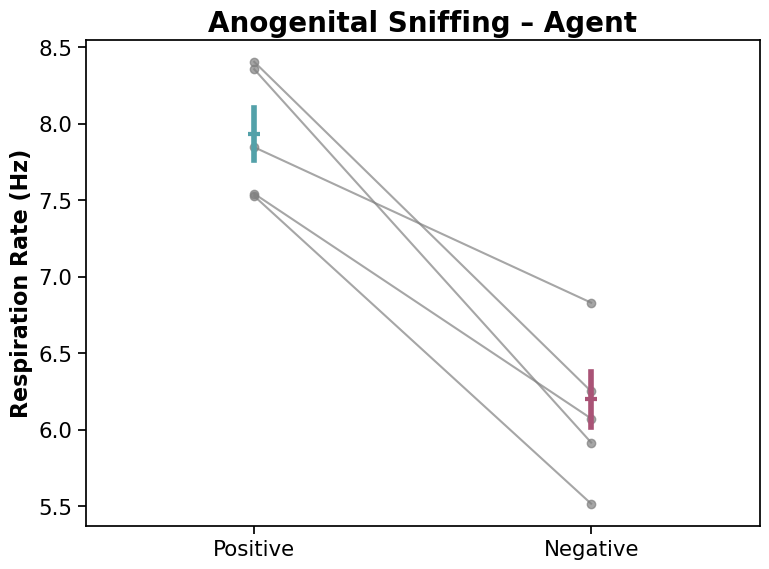


Summary of all paired t-tests:
              Behavior Initiator    t-stat   p-value
0      Facial Sniffing   Subject -2.555958  0.062907
1      Facial Sniffing     Agent  6.245485  0.001542
2        Body Sniffing   Subject -0.315454  0.768190
3        Body Sniffing     Agent  6.201789  0.001591
4  Anogenital Sniffing   Subject  0.606786  0.605699
5  Anogenital Sniffing     Agent  7.127820  0.002048


In [ ]:
# Define the behaviors and initiators you want to test/plot
behaviors = ['Facial Sniffing', 'Body Sniffing', 'Anogenital Sniffing']
initiators = ['Subject', 'Agent']

results_ttest = []

for behavior in behaviors:
    for initiator in initiators:
        print(f"\nRunning paired t-test for: {behavior} - {initiator}")
        t_stat, p = run_ttest_and_plot(behavior, initiator)
        results_ttest.append({
            'Behavior': behavior,
            'Initiator': initiator,
            't-stat': t_stat,
            'p-value': p
        })

# Optional: convert to DataFrame for a results table
results_df = pd.DataFrame(results_ttest)
print("\nSummary of all paired t-tests:")
print(results_df)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_paired_comparison(agg_df, behavior, initiator, palette):
    # Pivot to wide format for plotting
    pivot = agg_df.pivot(index="SubjectID", columns="Valence", values="Respiration Rate (Hz)").dropna()
    
    plt.figure(figsize=(8,6))
    sns.set_context("notebook", font_scale=1.5)
    
    # Plot subject lines
    for _, row in pivot.iterrows():
        plt.plot(["Positive", "Negative"], [row["Positive"], row["Negative"]],
                 marker="o", color="gray", alpha=0.7, linewidth=1.5)

    # Overlay group means with error bars
    sns.pointplot(data=agg_df, x="Valence", y="Respiration Rate (Hz)",
                  palette=palette, ci=68, join=False, markers="_", scale=1.5)

    plt.title(f"{behavior} – {initiator}", fontsize=20, weight="bold")
    plt.ylabel("Respiration Rate (Hz)", fontsize=16, weight="bold")
    plt.xlabel("")
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_behavior_initiator(df, behavior, initiator, ci=68):
    """
    Plot paired pre- vs during-sniff respiration rates for a given behavior × initiator.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain ['SubjectID', 'Behavior', 'Initiator', 'Condition', 'Respiration Rate (Hz)'].
    behavior : str
        Behavior name to filter (case-insensitive).
    initiator : str
        Initiator type to filter (e.g., 'Agent' or 'Subject').
    ci : int
        Confidence interval for group mean (default = 68%).
    """

    # Normalize behavior names to lowercase for filtering
    subset = df[
        (df["Behavior"].str.lower() == behavior.lower()) &
        (df["Initiator"].str.capitalize() == initiator.capitalize())
    ]

    if subset.empty:
        print(f"No data found for {behavior} - {initiator}")
        return

    plt.figure(figsize=(8, 6))
    sns.set_context("talk")

    # Plot individual subject lines
    for subj, subj_df in subset.groupby("SubjectID"):
        plt.plot(
            subj_df["Condition"],
            subj_df["Respiration Rate (Hz)"],
            marker="o", linestyle="-", alpha=0.6
        )

    # Overlay group mean ± CI
    sns.pointplot(
        data=subset,
        x="Condition", y="Respiration Rate (Hz)",
        color="black", ci=ci, markers="d", linestyles="-"
    )

    # Nice formatted title
    plt.title(f"Respiration Rate Change: {behavior.title()} ({initiator}-Initiated)")
    plt.ylabel("Respiration Rate (Hz)")
    plt.xlabel("")
    plt.legend([], [], frameon=False)  # hide subject legend
    plt.tight_layout()
    plt.show()


# Example: loop over all behaviors × initiators
behaviors = ['facial sniffing', 'body sniffing', 'anogenital sniffing']
initiators = ['Subject', 'Agent']

for b in behaviors:
    for i in initiators:
        plot_behavior_initiator(full_df, b, i)


KeyError: 'Condition'

<Figure size 800x600 with 0 Axes>

In [ ]:
print(full_df.columns)


Index(['Trial', 'Subject', 'Behavior', 'Start (s)', 'Stop (s)', 'Duration (s)',
       'Respiration Rate (Hz)', 'Valence', 'Initiator', 'SubjectID'],
      dtype='object')


In [ ]:
# Add a SubjectID column by extracting the 2nd and 3rd chunk of the trial name
combined_sniffs_df["SubjectID"] = combined_sniffs_df["Trial"].str.extract(r"RI\d_(\d+_\d+)")


In [ ]:
ri1_subjects = set(combined_sniffs_df[combined_sniffs_df["Trial"].str.startswith("RI1")]["SubjectID"].unique())
ri2_subjects = set(combined_sniffs_df[combined_sniffs_df["Trial"].str.startswith("RI2")]["SubjectID"].unique())

print(f"RI1 subjects: {sorted(ri1_subjects)}")
print(f"RI2 subjects: {sorted(ri2_subjects)}")
print(f"Subjects in both: {sorted(ri1_subjects & ri2_subjects)}")


RI1 subjects: ['1_1', '2_3', '2_4', '3_6', '4_8']
RI2 subjects: ['1_1', '1_2', '2_3', '2_4', '3_5', '3_6', '4_7', '4_8']
Subjects in both: ['1_1', '2_3', '2_4', '3_6', '4_8']


In [ ]:
def plot_resp_trace_from_boris_row(row, resp_data, pre=2, post=4):
    trial = row['Trial']
    start = row['Start (s)']
    stop = row['Stop (s)']
    behavior = row['Behavior']
    valence = row['Valence']

    # Check if trial exists in signal data
    if trial not in resp_data:
        print(f"⚠️ Trial {trial} not found in resp_data.")
        return

    signal = resp_data[trial]['signal']
    time = resp_data[trial]['time']

    # Time window around behavior
    mask = (time >= start - pre) & (time <= start + post)
    if not mask.any():
        print(f"⚠️ No signal data for {trial} around {start:.2f}s.")
        return

    clipped_time = time[mask] - start
    clipped_signal = signal[mask]

    # Plot
    plt.figure(figsize=(8, 3))
    plt.plot(clipped_time, clipped_signal, color='black', linewidth=1)
    plt.axvspan(0, stop - start, color='#53A1A9' if valence == 'Positive' else '#A95376', alpha=0.3)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f"{behavior.title()} | {valence} | {trial}")
    plt.xlabel("Time (s) from behavior onset")
    plt.ylabel("Respiration")
    plt.tight_layout()
    plt.show()


In [ ]:
pos_agent_df

,Trial,Subject,Behavior,Start (s),Stop (s),Duration (s),Respiration Rate (Hz),Valence
0,RI1_3_6,social_agent,anogenital sniffing,8.862,9.448,0.586,5.119454,Positive Social Interaction
2,RI1_3_6,social_agent,facial sniffing,12.069,12.862,0.793,7.566204,Positive Social Interaction
15,RI1_3_6,social_agent,anogenital sniffing,80.310,85.552,5.242,9.156810,Positive Social Interaction
16,RI1_3_6,social_agent,facial sniffing,86.207,87.414,1.207,7.456504,Positive Social Interaction
17,RI1_3_6,social_agent,facial sniffing,88.034,88.828,0.794,10.075567,Positive Social Interaction
18,RI1_3_6,social_agent,anogenital sniffing,90.690,91.862,1.172,7.679181,Positive Social Interaction
20,RI1_3_6,social_agent,facial sniffing,107.724,108.483,0.759,7.905138,Positive Social Interaction
21,RI1_3_6,social_agent,facial sniffing,183.724,184.621,0.897,8.918618,Positive Social Interaction
22,RI1_3_6,social_agent,facial sniffing,200.517,200.966,0.449,4.454343,Positive Social Interaction
23,RI1_3_6,social_agent,facial sniffing,217.172,217.655,0.483,8.281573,Positive Social Interaction
